In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import linregress
import config
import analysis_lib as alib

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Base period for climatological anomalies, pulled directly from your config
BASE_PERIOD = (config.START_YEAR, config.END_YEAR) 

# Ensure the output directories exist
config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
config.FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Setup complete. Climatology baseline set to: {BASE_PERIOD[0]}-{BASE_PERIOD[1]}")

✅ Setup complete. Climatology baseline set to: 1981-2014


In [4]:
# Time configurations for climatology and training
CLIM_START = 1975
CLIM_END   = 2014

# Expanded Index Definitions
INDEX_DEFINITIONS = {
    'IOD': ('subtract', 'wio', 'eio', 'standard'),
    'WIO': ('mean', 'wio', 'standard'),
    'EIO': ('mean', 'eio', 'standard'),
    'WPO': ('mean', 'wpo', 'standard'),
    'ENSO': ('mean', 'nino34', 'pacific'),
    'Niño1+2': ('mean', 'nino12', 'pacific'),
    'Niño3': ('mean', 'nino3', 'pacific'),
    'Niño4': ('mean', 'nino4', 'pacific')
}

In [5]:
# =============================================================================
# 2. LOAD PRE-CALCULATED INDICES & SST DATA
# =============================================================================

# 1. Load the Main Datasets (Indices)
print("Checking available periods defined in config.ANALYSIS_PERIODS...")
loaded_datasets = {}

for p in config.ANALYSIS_PERIODS.keys():
    f_path = config.OUTPUT_DIR / f"obs_regression_timeseries_{p.lower()}.nc"
    if f_path.exists():
        print(f" ✅ Loaded Index Data: {p}")
        loaded_datasets[p] = xr.open_dataset(f_path).load()

if not loaded_datasets:
    print(" ❌ WARNING: Could not find any index .nc files in OUTPUT_DIR.")

# 2. Load the SST Dataset (For GMST calculation)
print("\nAttempting to load SST dataset from config.SST_PATH...")
try:
    ds_sst = xr.open_mfdataset(config.SST_PATH, use_cftime=True, combine='by_coords')
    if 'latitude' in ds_sst: 
        ds_sst = ds_sst.rename({'latitude': 'lat', 'longitude': 'lon'})
    print(" ✅ SST dataset loaded successfully!")
except Exception as e:
    print(f" ❌ ERROR loading SST data: {e}")

Checking available periods defined in config.ANALYSIS_PERIODS...
 ✅ Loaded Index Data: MAM
 ✅ Loaded Index Data: March
 ✅ Loaded Index Data: April
 ✅ Loaded Index Data: May

Attempting to load SST dataset from config.SST_PATH...


 ✅ SST dataset loaded successfully!


In [6]:
import xesmf as xe
# =============================================================================
# 3. LOAD & PROCESS RAW PRECIPITATION (GPCC)
# =============================================================================

print(f"Attempting to load raw GPCC data from:\n{config.GPCC_PATH}")

try:
    # 1. Load Raw Data
    ds_gpcc = xr.open_mfdataset(config.GPCC_PATH, use_cftime=True, combine='by_coords')
    pr_var = 'precip' if 'precip' in ds_gpcc.data_vars else [v for v in ds_gpcc.data_vars if 'bnds' not in v][0]
    
    # 2. Regrid using your specific absolute path to weights
    print(" -> Applying pre-calculated conservative weights...")
    weights_path = "/nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/regridder_weights/weights_obs_gpcc_conservative.nc"
    
    regridder = xe.Regridder(
        ds_gpcc, config.DS_TARGET, 'conservative', 
        weights=weights_path, reuse_weights=True
    )
    ds_gpcc_regridded = regridder(ds_gpcc)
    
    # 3. Subset to Study Region
    bounds = config.BOUNDS['study']
    ds_study = ds_gpcc_regridded.sel(
        lat=slice(bounds['lat_min'], bounds['lat_max']),
        lon=slice(bounds['lon_min'], bounds['lon_max'])
    )
    
    # 4. Calculate Area-Weighted Spatial Mean
    weights = np.cos(np.deg2rad(ds_study.lat))
    pr_raw_monthly = ds_study[pr_var].weighted(weights).mean(dim=['lat', 'lon']).compute()
    print(pr_raw_monthly)
    
    print(" ✅ Raw precipitation time series successfully extracted!")
    
except Exception as e:
    print(f" ❌ ERROR processing raw GPCC data: {e}")

Attempting to load raw GPCC data from:
/nas/home/leo/Documents/haddata/gppc/*.nc
 -> Applying pre-calculated conservative weights...


<xarray.DataArray 'precip' (time: 600)> Size: 5kB
array([ 76.96447957,  74.12254201,  98.0841844 , 156.425508  ,
        84.77853714,  56.30947193,  17.59591198,   5.1719799 ,
         9.40559857,  17.18472866,  57.86011843,  82.68996484,
        74.74479702,  91.1552819 , 100.93991758, 120.60633641,
       138.2808183 ,  14.84618163,  23.94626808,  12.47229237,
        31.43128322,  72.87818222, 111.88817527, 101.23492024,
        98.49594907,  84.52530283,  78.26173103, 153.30460925,
        67.88611847,  47.72825022,   9.93894961,  13.11298806,
         6.81711388,  18.66547076,  82.7270347 ,  53.56124414,
        78.83225816,  47.36830136, 122.6859313 , 175.07253936,
        78.80259171,  28.40584527,  34.79771376,   6.34653138,
         7.58471294,  16.9638104 ,  46.04588052,  58.54926263,
        61.48110739,  45.73166846, 107.6360711 , 154.86174899,
        84.89427104,  41.13763517,  31.94999971,   5.34542369,
        26.89195773,  17.54891007,  57.18516387,  67.48983177,
     

In [7]:

# =============================================================================
# 4. CORE PREPROCESSING FUNCTIONS
# =============================================================================

def calculate_gmst_anomalies(ds_sst_in, target_years, base_period=BASE_PERIOD):
  #  """Calculates GMST anomalies using the pre-loaded SST dataset."""
    sst_var = 'sst' if 'sst' in ds_sst_in else [v for v in ds_sst_in.data_vars if 'bnds' not in v][0]
    
    weights = np.cos(np.deg2rad(ds_sst_in.lat))
    ds_weighted = ds_sst_in[sst_var].weighted(weights)
    
    gmst_monthly = ds_weighted.mean(dim=["lat", "lon"])
    gmst_annual = gmst_monthly.groupby('time.year').mean('time')
    
    gmst_clim = gmst_annual.sel(year=slice(str(base_period[0]), str(base_period[1]))).mean()
    gmst_anom = gmst_annual - gmst_clim
    
    return gmst_anom.compute().to_series().reindex(target_years)

def preprocess_period_data(df_in, pr_raw_ts, period_name, ds_sst_in, base_period=BASE_PERIOD):
    """
  #  Injects raw precip, calculates log, and computes base-period anomalies.
    """
    df = df_in.copy()
    
    # 1. Process Raw Precipitation for this specific period
    target_months = config.ANALYSIS_PERIODS[period_name]
    pr_period = pr_raw_ts.sel(time=pr_raw_ts['time.month'].isin(target_months))
    pr_annual_vals = pr_period.groupby('time.year').mean('time').to_series()
    
    # --- THE FIX: SAFELY MAP BY INTEGER YEAR ---
    # Extract the integer year from the existing dataframe
    df_years = df.index.year if hasattr(df.index, 'year') else df.index.values
    
    # Map the raw precipitation value to the exact year, defaulting to NaN if missing
    df['pr_raw'] = [pr_annual_vals.get(int(y), np.nan) for y in df_years]
    
    # 2. Log Transformation (Safe from negative numbers)
    df['pr_log'] = np.log(np.where(df['pr_raw'] > 0, df['pr_raw'], np.nan))
    
    # 3. Calculate Anomalies
    clim_mask = (df_years >= base_period[0]) & (df_years <= base_period[1])
    
    target_cols = ['pr_log'] + list(config.INDEX_DEFINITIONS.keys())
    
    for col in target_cols:
        if col in df.columns:
            clim_mean = df.loc[clim_mask, col].mean()
            df[f'{col}_anom'] = df[col] - clim_mean

    # 4. Integrate GMST Anomalies
    unique_years = np.unique(df_years)
    gw_anomaly_series = calculate_gmst_anomalies(ds_sst_in, unique_years, base_period=base_period)
    
    if hasattr(df.index, 'year'):
        df['GMST_anom'] = df.index.map(lambda x: gw_anomaly_series.get(x.year, np.nan))
    else:
        df['GMST_anom'] = gw_anomaly_series.loc[df.index].values

    return df


In [8]:
# =============================================================================
# 5. EXECUTE BATCH PREPROCESSING
# =============================================================================

preprocessed_dfs = {}

print("Starting batch preprocessing for all loaded periods...\n")

for period_name, ds in loaded_datasets.items():
    print(f"--- Processing: {period_name} ---")
    
    try:
        # Convert to dataframe and run through the master function
        df_base = ds.to_dataframe()
        df_processed = preprocess_period_data(df_base, pr_raw_monthly, period_name, ds_sst)
        
        preprocessed_dfs[period_name] = df_processed
        
        # --- VERIFICATION PRINT ---
        print(f" ✅ Success! Sample output for {period_name} (Last 5 years):")
        
        # Adding 'pr_log' to the display so you can see the log transformation too
        cols_to_show = ['pr_raw', 'pr_log', 'pr_log_anom', 'ENSO_anom', 'GMST_anom']
        existing_cols = [c for c in cols_to_show if c in df_processed.columns]
        
        # CHANGED: Using .tail(5) instead of .head(3) to see the most recent data
        display(df_processed[existing_cols].tail(5))
        print("-" * 60)
        
    except Exception as e:
        print(f" ❌ ERROR processing {period_name}: {e}")

if preprocessed_dfs:
    print("\n🎉 Batch processing complete! Your 'preprocessed_dfs' dictionary is fully populated and ready for regression modeling.")

Starting batch preprocessing for all loaded periods...

--- Processing: MAM ---


 ✅ Success! Sample output for MAM (Last 5 years):


,pr_raw,pr_log,pr_log_anom,ENSO_anom,GMST_anom
time,,,,,
2016,98.553953,4.590604,-0.087653,1.051785,0.171881
2017,124.012960,4.820386,0.142129,0.181620,0.195476
2018,194.714685,5.271535,0.593278,-0.355730,0.153729
2019,125.598144,4.833087,0.154830,0.710976,0.157551
2020,134.876957,4.904363,0.226106,0.279521,0.131696


------------------------------------------------------------
--- Processing: March ---
 ✅ Success! Sample output for March (Last 5 years):


,pr_raw,pr_log,pr_log_anom,ENSO_anom,GMST_anom
time,,,,,
2016,90.204913,4.502084,-0.193820,1.614395,0.171881
2017,94.966594,4.553525,-0.142379,-0.024764,0.195476
2018,186.981135,5.231008,0.535104,-0.651323,0.153729
2019,76.415667,4.336188,-0.359716,0.829804,0.157551
2020,173.747962,5.157606,0.461702,0.397992,0.131696


------------------------------------------------------------
--- Processing: April ---
 ✅ Success! Sample output for April (Last 5 years):


,pr_raw,pr_log,pr_log_anom,ENSO_anom,GMST_anom
time,,,,,
2016,179.987477,5.192887,0.342069,1.060251,0.171881
2017,133.294821,4.892563,0.041745,0.252871,0.195476
2018,257.951115,5.552770,0.701952,-0.316245,0.153729
2019,120.991317,4.795719,-0.055100,0.684618,0.157551
2020,184.535276,5.217841,0.367022,0.518830,0.131696


------------------------------------------------------------
--- Processing: May ---
 ✅ Success! Sample output for May (Last 5 years):


,pr_raw,pr_log,pr_log_anom,ENSO_anom,GMST_anom
time,,,,,
2016,25.469470,3.237480,-1.074726,0.480710,0.171881
2017,143.777465,4.968267,0.656061,0.316752,0.195476
2018,139.211806,4.935997,0.623791,-0.099624,0.153729
2019,179.387447,5.189548,0.877342,0.618506,0.157551
2020,46.347632,3.836170,-0.476036,-0.078260,0.131696


------------------------------------------------------------

🎉 Batch processing complete! Your 'preprocessed_dfs' dictionary is fully populated and ready for regression modeling.


In [9]:
# =============================================================================
# 6. GRAM-SCHMIDT ORTHOGONALIZATION
# =============================================================================

def project_vector(v, u):
    """
    Computes the mathematical projection of vector v onto vector u.
    Formula: proj_u(v) = (<v, u> / <u, u>) * u
    """
    # Add a tiny epsilon to the denominator to prevent zero-division errors
    epsilon = 1e-10
    return (np.dot(v, u) / (np.dot(u, u) + epsilon)) * u

def apply_gram_schmidt(df_in):
    """
    Isolates independent climate signals by sequentially removing the 
    variance explained by higher-priority modes in the hierarchy.
    """
    df = df_in.copy()
    
    # Define the strict physical hierarchy requested
    # Mapping 'WestPac' to the existing 'WPO_anom' and 'Nino3/1+2' to 'Niño1+2_anom'
    hierarchy = [
        'GMST_anom',      # u1: Thermodynamic forcing
        'ENSO_anom',      # u2: Basin-wide Pacific coupled mode
        'Niño4_anom',     # u3: Central Pacific / Modoki flavor
        'Niño1+2_anom',   # u4: Extreme Eastern Pacific coastal mode
        'WIO_anom',       # u5: Western Indian Ocean local dynamics
        'WPO_anom'        # u6: Western Pacific local dynamics
    ]
    
    # 1. Ensure vectors contain no NaNs during the vector dot-product calculation
    valid_cols = [c for c in hierarchy if c in df.columns]
    mask = df[valid_cols].notna().all(axis=1)
    
    basis_vectors = []
    
    # 2. Sequential Orthogonalization
    for col in valid_cols:
        v = df.loc[mask, col].values
        
        # Start with the raw anomaly vector
        u = v.copy()
        
        # Subtract the projection onto all previously defined orthogonal vectors
        for b in basis_vectors:
            u = u - project_vector(v, b)
            
        basis_vectors.append(u)
        
        # 3. Store the Orthogonal Vector
        ortho_name = f"{col}_ortho"
        df.loc[mask, ortho_name] = u
        
        # 4. Scale to Unit Length (Orthonormalization)
        norm = np.linalg.norm(u)
        if norm > 0:
            e = u / norm
        else:
            e = u
            
        orthonormal_name = f"{col}_orthonormal"
        df.loc[mask, orthonormal_name] = e
        
    return df

In [10]:
# =============================================================================
# 7. EXECUTE ORTHOGONALIZATION ON ALL PERIODS
# =============================================================================

# Dictionary to store the dynamically isolated dataframes
orthogonalized_dfs = {}

print("Applying Gram-Schmidt hierarchy to all periods...\n")

for period_name, df_processed in preprocessed_dfs.items():
    print(f"--- Orthogonalizing: {period_name} ---")
    
    try:
        # Apply the Gram-Schmidt transformation
        df_ortho = apply_gram_schmidt(df_processed)
        orthogonalized_dfs[period_name] = df_ortho
        
        # --- VERIFICATION PRINT ---
        print(f" ✅ Success! Extracted orthonormal basis vectors.")
        
        # Verify strict orthogonality using the dot product of GMST and ENSO
        if 'GMST_anom_orthonormal' in df_ortho.columns and 'ENSO_anom_orthonormal' in df_ortho.columns:
            # Mask out NaNs for the verification calculation
            mask = df_ortho['GMST_anom_orthonormal'].notna()
            u1 = df_ortho.loc[mask, 'GMST_anom_orthonormal'].values
            u2 = df_ortho.loc[mask, 'ENSO_anom_orthonormal'].values
            
            dot_product = np.dot(u1, u2)
            print(f"    [Math Check] Dot product of e1 (GMST) & e2 (ENSO): {dot_product:.2e}")
            if abs(dot_product) < 1e-10:
                print("    -> Confirmed: Vectors are strictly orthogonal.")
            else:
                print("    -> ⚠️ WARNING: Vectors are not perfectly orthogonal.")
                
        # Display the first few rows of the final orthonormal signals
        ortho_cols = [c for c in df_ortho.columns if 'orthonormal' in c]
        display(df_ortho[ortho_cols].head(3))
        print("-" * 60)
        
    except Exception as e:
        print(f" ❌ ERROR processing {period_name}: {e}")

if orthogonalized_dfs:
    print("\n🎉 Gram-Schmidt orthogonalization complete. Predictors are now strictly independent.")

Applying Gram-Schmidt hierarchy to all periods...

--- Orthogonalizing: MAM ---
 ✅ Success! Extracted orthonormal basis vectors.
    [Math Check] Dot product of e1 (GMST) & e2 (ENSO): 1.13e-11
    -> Confirmed: Vectors are strictly orthogonal.


,GMST_anom_orthonormal,ENSO_anom_orthonormal,Niño4_anom_orthonormal,Niño1+2_anom_orthonormal,WIO_anom_orthonormal,WPO_anom_orthonormal
time,,,,,,
1950,-0.213790,-0.149060,0.052047,0.067845,-0.019659,0.084495
1951,-0.180484,0.001441,-0.096982,0.035548,-0.154581,-0.131523
1952,-0.145029,0.074624,0.049742,0.000362,-0.014141,-0.018607


------------------------------------------------------------
--- Orthogonalizing: March ---
 ✅ Success! Extracted orthonormal basis vectors.
    [Math Check] Dot product of e1 (GMST) & e2 (ENSO): 8.38e-12
    -> Confirmed: Vectors are strictly orthogonal.


,GMST_anom_orthonormal,ENSO_anom_orthonormal,Niño4_anom_orthonormal,Niño1+2_anom_orthonormal,WIO_anom_orthonormal,WPO_anom_orthonormal
time,,,,,,
1950,-0.213790,-0.113350,0.002539,-0.012005,0.007541,0.093839
1951,-0.180484,-0.072119,-0.045013,0.021842,0.008188,-0.249893
1952,-0.145029,0.062122,-0.025545,0.054302,0.004496,-0.002863


------------------------------------------------------------
--- Orthogonalizing: April ---
 ✅ Success! Extracted orthonormal basis vectors.
    [Math Check] Dot product of e1 (GMST) & e2 (ENSO): 1.04e-11
    -> Confirmed: Vectors are strictly orthogonal.


,GMST_anom_orthonormal,ENSO_anom_orthonormal,Niño4_anom_orthonormal,Niño1+2_anom_orthonormal,WIO_anom_orthonormal,WPO_anom_orthonormal
time,,,,,,
1950,-0.213790,-0.116532,0.012432,-0.061662,-0.116952,0.154685
1951,-0.180484,0.034121,-0.172533,-0.035925,-0.266889,-0.127552
1952,-0.145029,0.155210,0.001480,-0.149770,-0.020294,-0.012659


------------------------------------------------------------
--- Orthogonalizing: May ---
 ✅ Success! Extracted orthonormal basis vectors.
    [Math Check] Dot product of e1 (GMST) & e2 (ENSO): 1.33e-11
    -> Confirmed: Vectors are strictly orthogonal.


,GMST_anom_orthonormal,ENSO_anom_orthonormal,Niño4_anom_orthonormal,Niño1+2_anom_orthonormal,WIO_anom_orthonormal,WPO_anom_orthonormal
time,,,,,,
1950,-0.213790,-0.195244,0.091760,0.232581,-0.007744,0.013130
1951,-0.180484,0.064761,-0.048525,0.071778,-0.126913,-0.001447
1952,-0.145029,-0.009517,0.176681,0.142188,-0.042069,-0.027751


------------------------------------------------------------

🎉 Gram-Schmidt orthogonalization complete. Predictors are now strictly independent.


In [11]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# =============================================================================
# 8. VIF (MULTICOLLINEARITY) CHECK
# =============================================================================

print("Running VIF Check on Orthonormal Predictors...\n")

for period_name, df_ortho in orthogonalized_dfs.items():
    print(f"--- VIF Diagnostics: {period_name} ---")
    
    # 1. Identify our orthonormal predictors
    X_cols = [c for c in df_ortho.columns if 'orthonormal' in c]
    
    # 2. Drop any NaNs to ensure the matrix math works
    df_clean = df_ortho[X_cols].dropna()
    
    if df_clean.empty:
        print(" ❌ ERROR: No valid data available for VIF calculation.")
        continue
        
    # 3. Add a constant (intercept) for the VIF calculation
    X = sm.add_constant(df_clean)
    
    # 4. Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    # Filter out the constant to just show the predictors
    display(vif_data[vif_data["Feature"] != "const"].round(3))
    print(" (Note: A VIF of exactly 1.0 confirms perfect orthogonality)\n" + "-"*60)

Running VIF Check on Orthonormal Predictors...

--- VIF Diagnostics: MAM ---


,Feature,VIF
1,GMST_anom_orthonormal,1.030
2,ENSO_anom_orthonormal,1.011
3,Niño4_anom_orthonormal,1.015
4,Niño1+2_anom_orthonormal,1.006
5,WIO_anom_orthonormal,1.002
6,WPO_anom_orthonormal,1.001


 (Note: A VIF of exactly 1.0 confirms perfect orthogonality)
------------------------------------------------------------
--- VIF Diagnostics: March ---


,Feature,VIF
1,GMST_anom_orthonormal,1.021
2,ENSO_anom_orthonormal,1.008
3,Niño4_anom_orthonormal,1.011
4,Niño1+2_anom_orthonormal,1.003
5,WIO_anom_orthonormal,1.001
6,WPO_anom_orthonormal,1.000


 (Note: A VIF of exactly 1.0 confirms perfect orthogonality)
------------------------------------------------------------
--- VIF Diagnostics: April ---


,Feature,VIF
1,GMST_anom_orthonormal,1.028
2,ENSO_anom_orthonormal,1.014
3,Niño4_anom_orthonormal,1.012
4,Niño1+2_anom_orthonormal,1.002
5,WIO_anom_orthonormal,1.001
6,WPO_anom_orthonormal,1.004


 (Note: A VIF of exactly 1.0 confirms perfect orthogonality)
------------------------------------------------------------
--- VIF Diagnostics: May ---


,Feature,VIF
1,GMST_anom_orthonormal,1.034
2,ENSO_anom_orthonormal,1.006
3,Niño4_anom_orthonormal,1.023
4,Niño1+2_anom_orthonormal,1.009
5,WIO_anom_orthonormal,1.001
6,WPO_anom_orthonormal,1.001


 (Note: A VIF of exactly 1.0 confirms perfect orthogonality)
------------------------------------------------------------


In [12]:
# =============================================================================
# 9. OLS REGRESSION & METRICS SUMMARY (STRICT TRAINING PERIOD)
# =============================================================================
import statsmodels.api as sm
import pandas as pd

fitted_models = {}

print("Running Robust OLS Regression (Strictly 1981-2014)...\n")

for period_name, df_ortho in orthogonalized_dfs.items():
    print(f"--- Regression Results: {period_name} ---")
    
    target_col = 'pr_log_anom'
    #target_col = 'pr_anom'
    predictor_cols = [c for c in df_ortho.columns if 'orthonormal' in c]
    
    # 1. Define the strict Training Mask
    years = df_ortho.index.year if hasattr(df_ortho.index, 'year') else df_ortho.index.values
    mask_train = (years >= config.START_YEAR) & (years <= config.END_YEAR)
    
    # 2. Extract ONLY the training data
    df_train = df_ortho.loc[mask_train, [target_col] + predictor_cols].dropna()
    
    if df_train.empty:
        print(" ❌ ERROR: Not enough valid data to run regression.")
        continue
        
    y_train = df_train[target_col]
    X_train = sm.add_constant(df_train[predictor_cols])
    
    # 3. Fit Model
    model = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    fitted_models[period_name] = model
    
    print(" ✅ Model trained successfully on base period.")
    print(f"    R-squared (Raw):    {model.rsquared:.4f}")
    print(f"    Adjusted R-squared: {model.rsquared_adj:.4f}\n")
    
    summary_df = pd.DataFrame({
        'Coefficient (Beta)': model.params,
        'Robust SE (HAC)': model.bse,
        'p-value': model.pvalues
    })
    
    display(summary_df.drop('const').round(4))
    print("-" * 60)

Running Robust OLS Regression (Strictly 1981-2014)...

--- Regression Results: MAM ---
 ✅ Model trained successfully on base period.
    R-squared (Raw):    0.2402
    Adjusted R-squared: 0.0714



,Coefficient (Beta),Robust SE (HAC),p-value
GMST_anom_orthonormal,-1.5527,0.6381,0.0150
ENSO_anom_orthonormal,0.3822,0.1561,0.0144
Niño4_anom_orthonormal,0.3137,0.1374,0.0224
Niño1+2_anom_orthonormal,0.3595,0.3137,0.2518
WIO_anom_orthonormal,-0.0204,0.1846,0.9120
WPO_anom_orthonormal,-0.0601,0.1825,0.7421


------------------------------------------------------------
--- Regression Results: March ---
 ✅ Model trained successfully on base period.
    R-squared (Raw):    0.1779
    Adjusted R-squared: -0.0048



,Coefficient (Beta),Robust SE (HAC),p-value
GMST_anom_orthonormal,-0.5228,0.6135,0.3942
ENSO_anom_orthonormal,-0.1256,0.2706,0.6425
Niño4_anom_orthonormal,0.4651,0.2336,0.0465
Niño1+2_anom_orthonormal,0.3628,0.3028,0.2308
WIO_anom_orthonormal,0.5171,0.2576,0.0447
WPO_anom_orthonormal,-0.2585,0.3754,0.4911


------------------------------------------------------------
--- Regression Results: April ---
 ✅ Model trained successfully on base period.
    R-squared (Raw):    0.1037
    Adjusted R-squared: -0.0955



,Coefficient (Beta),Robust SE (HAC),p-value
GMST_anom_orthonormal,-0.7356,0.5895,0.2121
ENSO_anom_orthonormal,0.3516,0.3446,0.3075
Niño4_anom_orthonormal,-0.0012,0.2762,0.9965
Niño1+2_anom_orthonormal,0.2803,0.3570,0.4324
WIO_anom_orthonormal,-0.4969,0.3593,0.1667
WPO_anom_orthonormal,0.1492,0.3476,0.6677


------------------------------------------------------------
--- Regression Results: May ---
 ✅ Model trained successfully on base period.
    R-squared (Raw):    0.5045
    Adjusted R-squared: 0.3944



,Coefficient (Beta),Robust SE (HAC),p-value
GMST_anom_orthonormal,-3.8342,1.3588,0.0048
ENSO_anom_orthonormal,0.7559,0.2531,0.0028
Niño4_anom_orthonormal,0.8628,0.5657,0.1272
Niño1+2_anom_orthonormal,0.5441,0.7968,0.4947
WIO_anom_orthonormal,2.1969,1.0012,0.0282
WPO_anom_orthonormal,-0.2175,0.4809,0.6510


------------------------------------------------------------


Generating Clean Smoothed Reconstruction Plots (Composite)...

--- Reconstructing (Smoothed Only): MAM ---
--- Reconstructing (Smoothed Only): March ---
--- Reconstructing (Smoothed Only): April ---
--- Reconstructing (Smoothed Only): May ---


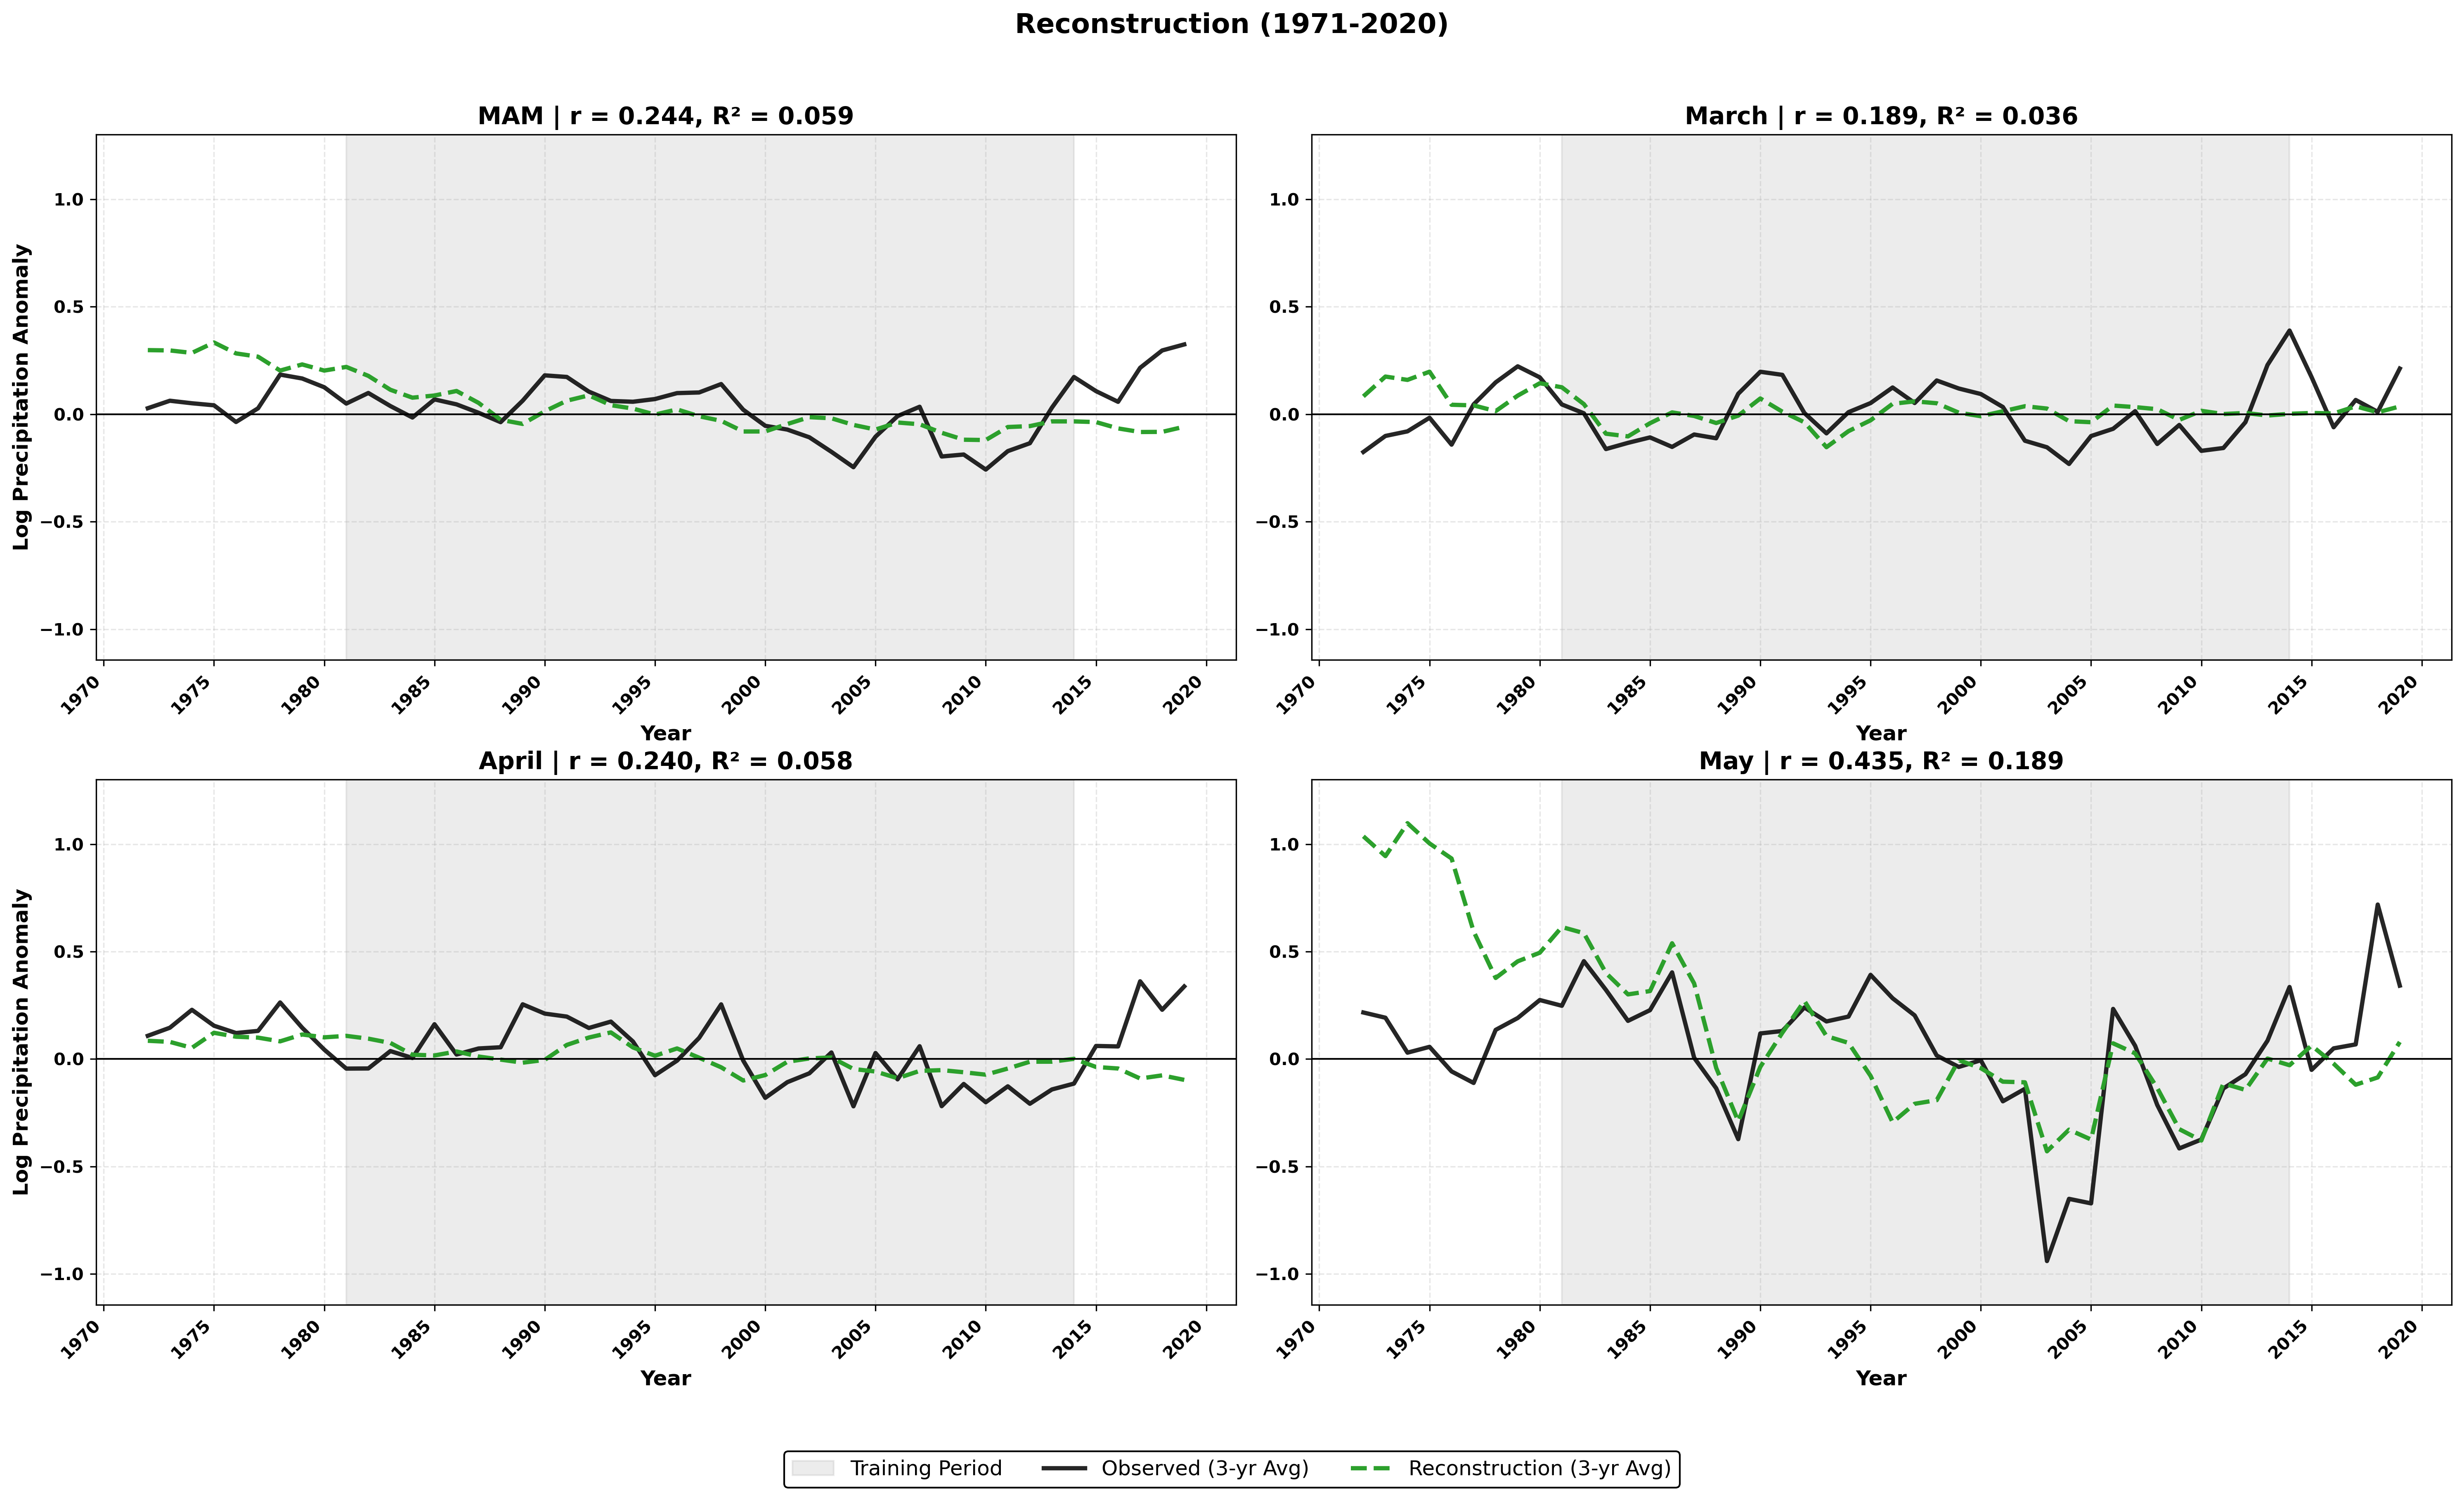

 💾 Saved composite 3-yr smoothed plot: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/reconstruction_full_ts_3yr_smooth_composite.png
------------------------------------------------------------


In [14]:
# =============================================================================
# 13. FULL TIMELINE RECONSTRUCTION (SMOOTHED ONLY)
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import statsmodels.api as sm
import math

print("Generating Clean Smoothed Reconstruction Plots (Composite)...\n")

# Define the moving average window (e.g., 3 or 5 years)
WINDOW = 3 

# Determine optimal multi-panel grid layout
num_periods = len(fitted_models)
cols = 2 if num_periods > 1 else 1
rows = math.ceil(num_periods / cols)

# Initialize a single composite figure
fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 6 * rows), dpi=300)

# Ensure axes is iterable even if there's only one plot
if num_periods == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Variables to track the absolute limits for unifying the y-axis
global_min_y = float('inf')
global_max_y = float('-inf')

for i, (period_name, model) in enumerate(fitted_models.items()):
    print(f"--- Reconstructing (Smoothed Only): {period_name} ---")
    
    ax = axes[i]
    
    # 1. Grab ALL available valid data (1950 - 2020)
    df_ortho = orthogonalized_dfs[period_name]
    
    # Dynamically detect if we are using linear or log anomalies
    target_col = 'pr_anom' if 'pr_anom' in df_ortho.columns else 'pr_log_anom'
    predictor_cols = [c for c in df_ortho.columns if 'orthonormal' in c]
    
    df_full = df_ortho[[target_col] + predictor_cols].dropna()
    y_actual_full = df_full[target_col]
    X_full = sm.add_constant(df_full[predictor_cols])
    
    # 2. PREDICT out-of-sample using our base training period model rules
    y_predicted_full = model.predict(X_full)
    years = y_actual_full.index.year if hasattr(y_actual_full.index, 'year') else y_actual_full.index.values
    
    # 3. Calculate the Moving Average on the FULL timeline
    y_actual_smooth = y_actual_full.rolling(WINDOW, center=True).mean()
    y_predicted_smooth = y_predicted_full.rolling(WINDOW, center=True).mean()
    
    # Calculate Correlation specifically on the Smoothed Data
    valid_smooth = y_actual_smooth.notna() & y_predicted_smooth.notna()
    
    if valid_smooth.sum() > 2:
        r_val_smooth = np.corrcoef(y_actual_smooth[valid_smooth], y_predicted_smooth[valid_smooth])[0, 1]
        r_sq_smooth = r_val_smooth**2
    else:
        r_val_smooth, r_sq_smooth = np.nan, np.nan
        
    # 4. Plotting on the specific subplot axis
    # Highlight the Training Period
    ax.axvspan(config.START_YEAR, config.END_YEAR, color='gray', alpha=0.15, label='Training Period')
    
    # Plot ONLY the Smoothed Data
    ax.plot(years, y_actual_smooth, color='black', linewidth=2.5, alpha=0.85, label=f'Observed ({WINDOW}-yr Avg)')
    ax.plot(years, y_predicted_smooth, color='tab:green', linewidth=2.5, linestyle='--', label=f'Reconstruction ({WINDOW}-yr Avg)')
    
    # Formatting
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f"{period_name} | r = {r_val_smooth:.3f}, R² = {r_sq_smooth:.3f}", 
                 fontsize=14, fontweight='bold')
    
    # Only add y-labels to the leftmost columns to reduce clutter (Make label bold)
    if i % cols == 0:
        label_text = "Precipitation Anomaly" if target_col == 'pr_anom' else "Log Precipitation Anomaly"
        ax.set_ylabel(label_text, fontsize=12, fontweight='bold')
        
    # Make x-axis label bold
    ax.set_xlabel("Year", fontsize=12, fontweight='bold')
    
    # Enforce 5-year intervals on the x-axis
    ax.xaxis.set_major_locator(MultipleLocator(5))
    
    # Apply bold formatting to the tick labels (numbers) on both axes
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Track limits for unified y-axis
    local_min = min(y_actual_smooth.min(), y_predicted_smooth.min())
    local_max = max(y_actual_smooth.max(), y_predicted_smooth.max())
    global_min_y = min(global_min_y, local_min)
    global_max_y = max(global_max_y, local_max)

# Apply the unified y-axis scale to all active subplots
y_padding = (global_max_y - global_min_y) * 0.1
for ax in axes[:num_periods]:
    ax.set_ylim(global_min_y - y_padding, global_max_y + y_padding)

# Remove any empty subplots if the number of periods doesn't perfectly fill the grid
for j in range(num_periods, len(axes)):
    fig.delaxes(axes[j])

# Apply global title and tighten layout
plt.suptitle(f"Reconstruction (1971-2020)", 
             fontsize=16, fontweight='bold', y=1.02)

# Adjust layout to make room for the global legend at the bottom
plt.tight_layout()
fig.subplots_adjust(bottom=0.15) 

# Extract handles and labels from the first subplot to create a single global legend
handles, labels = axes[0].get_legend_handles_labels()

# Re-enable the frame (box) for the legend with a solid border
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12, 
           bbox_to_anchor=(0.5, 0.02), frameon=True, edgecolor='black', framealpha=1.0)

# Save the multi-panel figure
save_path = config.FIGURE_DIR / f"reconstruction_full_ts_{WINDOW}yr_smooth_composite.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" 💾 Saved composite {WINDOW}-yr smoothed plot: {save_path}")
print("-" * 60)

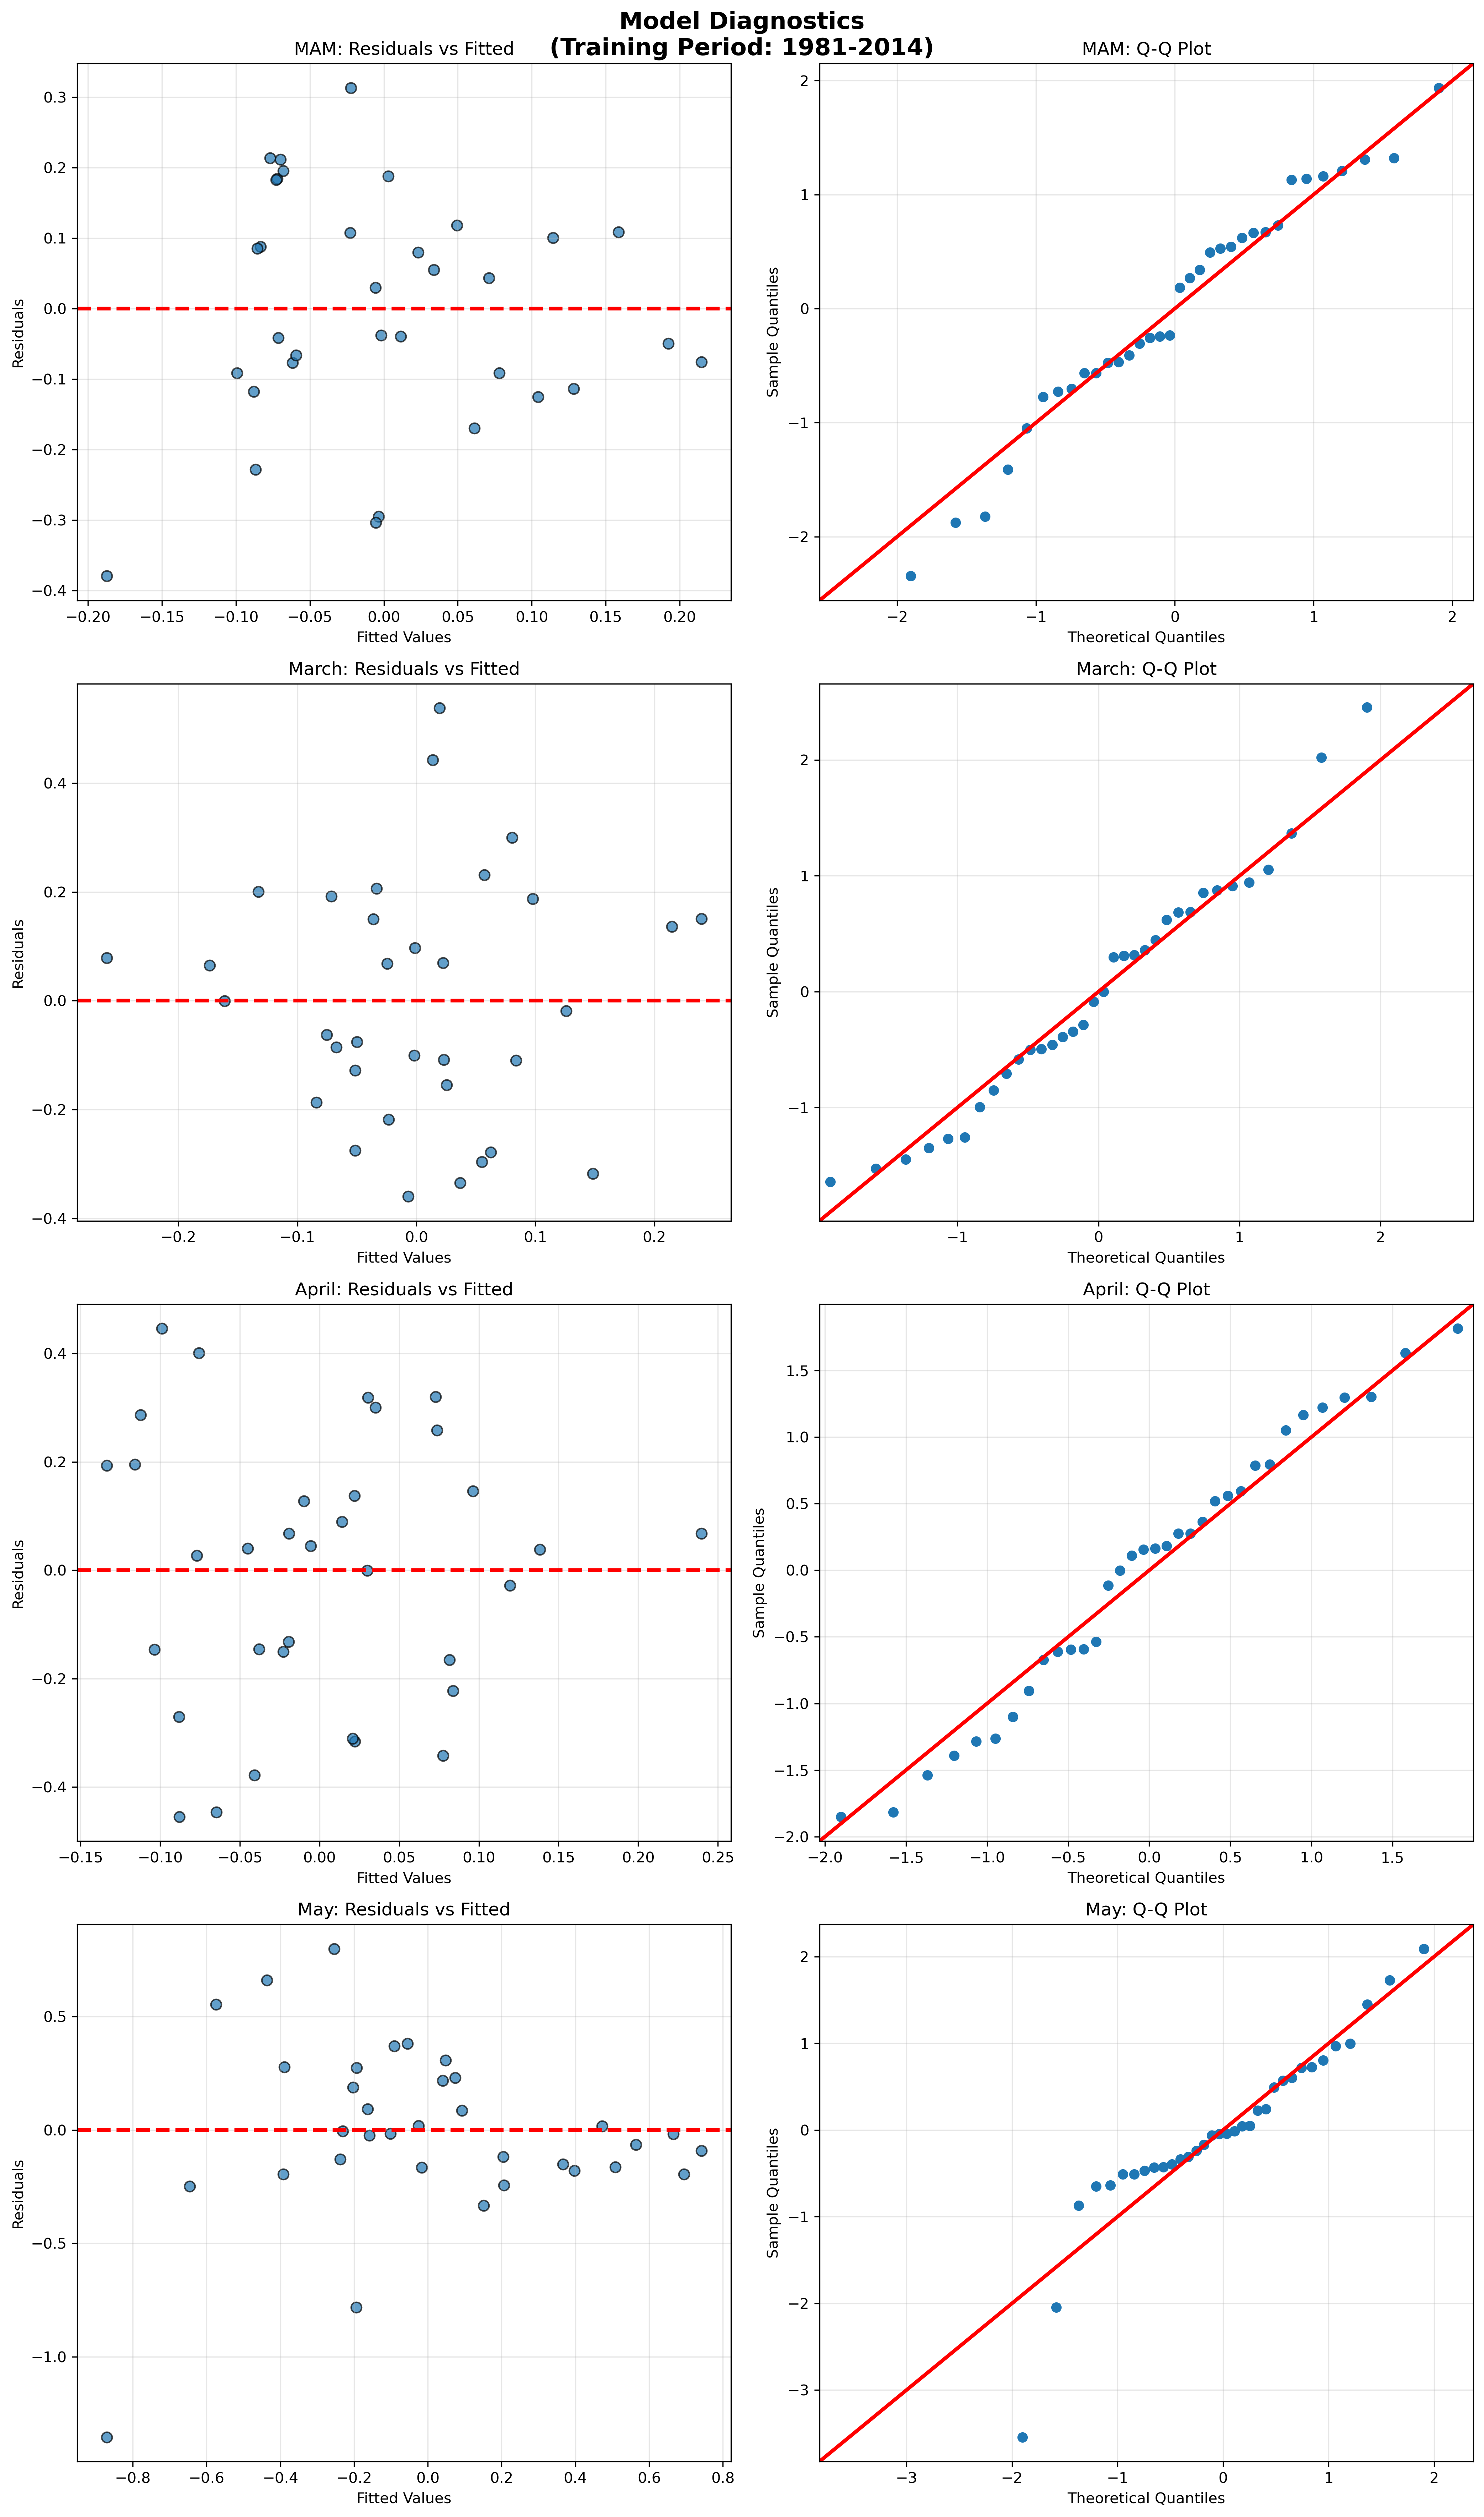

In [16]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

n_periods = len(fitted_models)

fig, axes = plt.subplots(
    n_periods, 2,
    figsize=(14, 6 * n_periods),
    dpi=300
)

# Handle case where only one period exists
if n_periods == 1:
    axes = [axes]

for i, (period_name, model) in enumerate(fitted_models.items()):

    fitted_vals = model.fittedvalues
    residuals = model.resid

    # Residuals vs Fitted
    axes[i][0].scatter(
        fitted_vals, residuals,
        alpha=0.7, color='tab:blue',
        edgecolors='k', s=50
    )
    axes[i][0].axhline(0, color='red', linestyle='--', linewidth=2.5)
    axes[i][0].set_title(f'{period_name}: Residuals vs Fitted')
    axes[i][0].set_xlabel('Fitted Values')
    axes[i][0].set_ylabel('Residuals')
    axes[i][0].grid(True, alpha=0.3)

    # QQ plot
    sm.qqplot(
        residuals,
        line='45',
        fit=True,
        ax=axes[i][1]
    )

    if len(axes[i][1].get_lines()) > 1:
        axes[i][1].get_lines()[1].set_color('red')
        axes[i][1].get_lines()[1].set_linewidth(2.5)

    axes[i][1].set_title(f'{period_name}: Q-Q Plot')
    axes[i][1].grid(True, alpha=0.3)

fig.suptitle(
    f"Model Diagnostics\n(Training Period: {config.START_YEAR}-{config.END_YEAR})",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    config.FIGURE_DIR / "diagnostics_all_periods.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Generating Residual Trend Plots with Standard Deviation Boundaries...

--- Processing Residuals: MAM ---
--- Processing Residuals: March ---
--- Processing Residuals: April ---
--- Processing Residuals: May ---


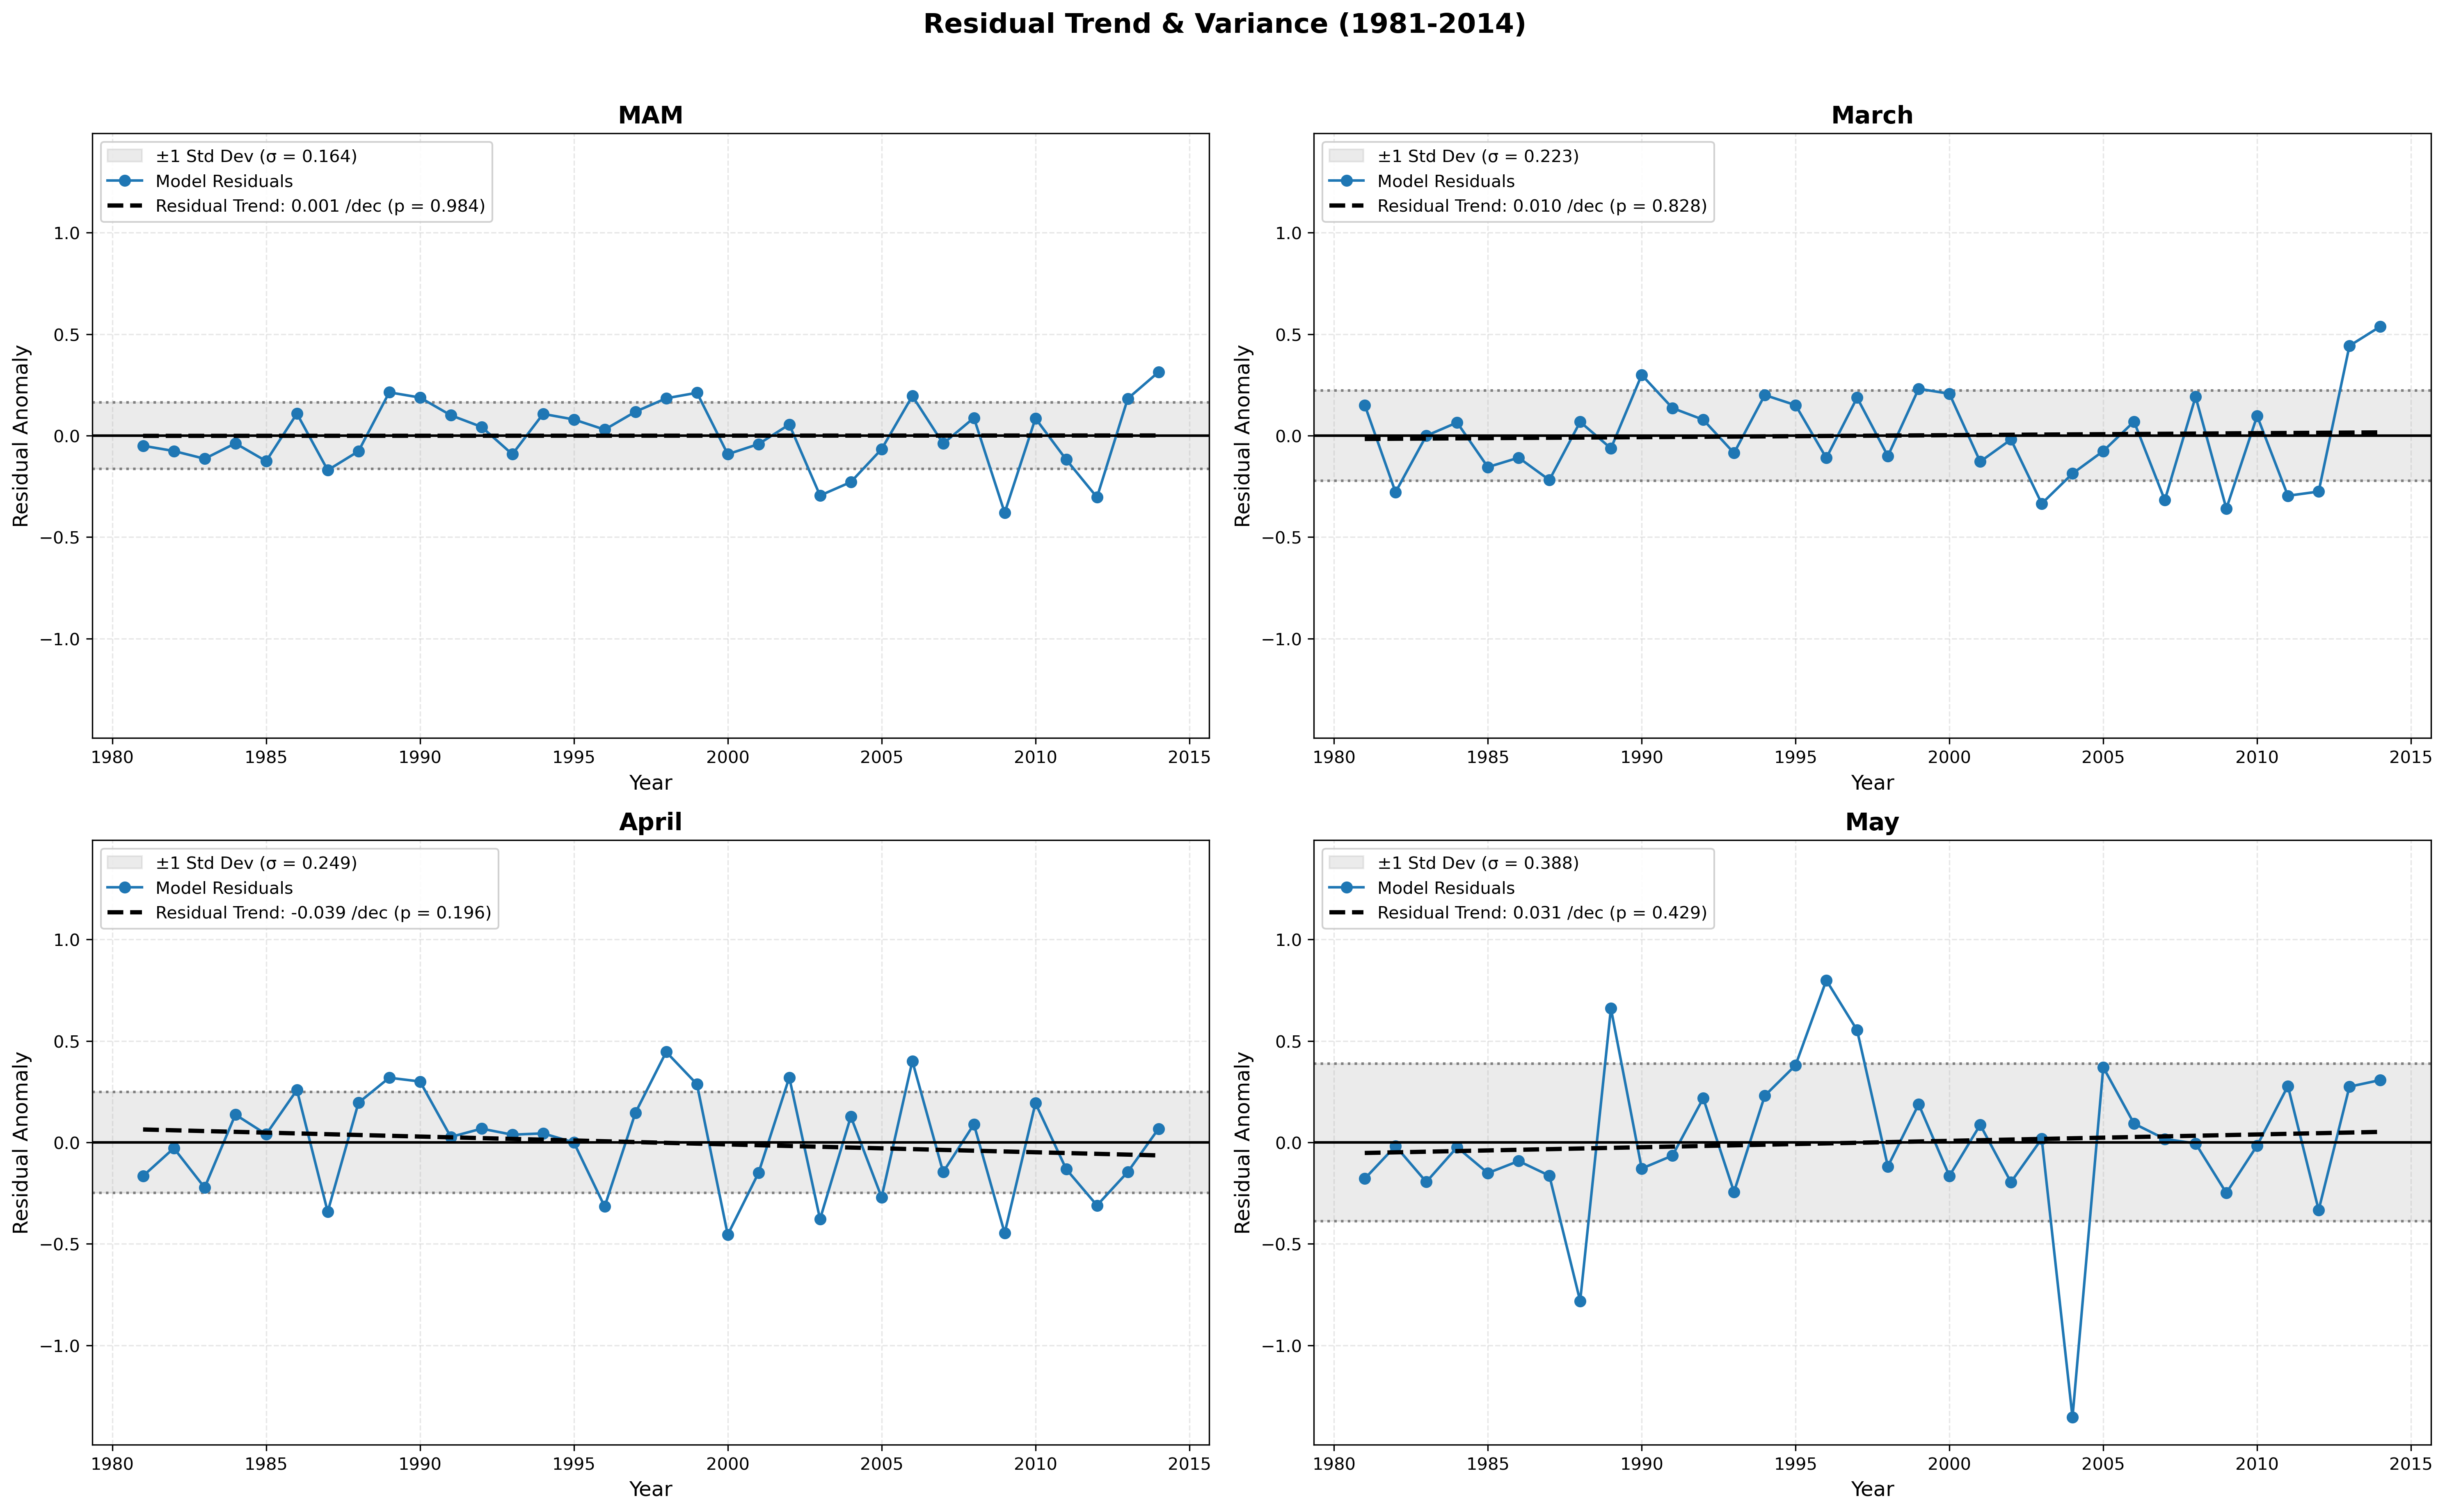

 💾 Saved composite residual trend plot: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/residual_trend_std_composite.png
------------------------------------------------------------


In [17]:
# =============================================================================
# 16. RESIDUAL TREND & STANDARD DEVIATION ANALYSIS
# =============================================================================
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import math

print("Generating Residual Trend Plots with Standard Deviation Boundaries...\n")

# Determine optimal multi-panel grid layout
num_periods = len(fitted_models)
cols = 2 if num_periods > 1 else 1
rows = math.ceil(num_periods / cols)

# Initialize a single composite figure
fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 6 * rows), dpi=300)

# Ensure axes is iterable even if there's only one plot
if num_periods == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Variable to track the absolute maximum value for unifying the y-axis
global_max_y = 0.0

for i, (period_name, model) in enumerate(fitted_models.items()):
    print(f"--- Processing Residuals: {period_name} ---")
    
    ax = axes[i]
    
    # 1. Extract Residuals and Time Index (Strictly from the Training Period)
    resid_series = model.resid
    valid_years = resid_series.index.year if hasattr(resid_series.index, 'year') else resid_series.index.values
    
    # 2. Calculate the Standard Deviation of the Residuals
    std_dev = resid_series.std()
    
    # 3. Calculate the Trend of the Residuals using Robust OLS (HAC)
    X_time = sm.add_constant(valid_years)
    trend_model = sm.OLS(resid_series.values, X_time).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    
    # Extract slope (scale to decadal trend) and p-value
    slope_annual = trend_model.params[1]
    slope_decadal = slope_annual * 10 
    p_val = trend_model.pvalues[1]
    
    # Generate the trend line points
    trend_line = trend_model.predict(X_time)
    
    # 4. Plotting on the specific subplot axis
    # Plot the ±1 Standard Deviation boundaries (Shaded region)
    ax.axhspan(-std_dev, std_dev, color='tab:gray', alpha=0.15, label=f'±1 Std Dev (σ = {std_dev:.3f})')
    ax.axhline(std_dev, color='tab:gray', linestyle=':', linewidth=1.5)
    ax.axhline(-std_dev, color='tab:gray', linestyle=':', linewidth=1.5)
    
    # Plot the residual time series
    ax.plot(valid_years, resid_series.values, color='tab:blue', marker='o', linestyle='-', 
            linewidth=1.5, markersize=6, label='Model Residuals')
    
    # Plot the trend line
    trend_color = 'tab:red' if p_val < 0.05 else 'black'
    trend_style = '-' if p_val < 0.05 else '--'
    
    # Clean p-value formatting for the legend
    p_val_str = "< 0.001" if p_val < 0.001 else f"{p_val:.3f}"
    ax.plot(valid_years, trend_line, color=trend_color, linestyle=trend_style, linewidth=2.5,
            label=f'Residual Trend: {slope_decadal:.3f} /dec (p = {p_val_str})')
    
    # Formatting
    ax.axhline(0, color='black', linewidth=1.5)
    ax.set_title(f"{period_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Residual Anomaly", fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Place legend inside the subplot to keep the composite clean
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    
    # Track the absolute maximum limit required across all subplots
    local_max = max(abs(resid_series.max()), abs(resid_series.min()), std_dev * 1.5) * 1.1
    global_max_y = max(global_max_y, local_max)

# Apply the unified y-axis scale to all active subplots
for ax in axes[:num_periods]:
    ax.set_ylim(-global_max_y, global_max_y)

# Remove any empty subplots if the number of periods doesn't perfectly fill the grid
for j in range(num_periods, len(axes)):
    fig.delaxes(axes[j])

# Apply a global title and tighten layout
plt.suptitle(f"Residual Trend & Variance ({config.START_YEAR}-{config.END_YEAR})", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the multi-panel figure
save_path = config.FIGURE_DIR / "residual_trend_std_composite.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" 💾 Saved composite residual trend plot: {save_path}")
print("-" * 60)

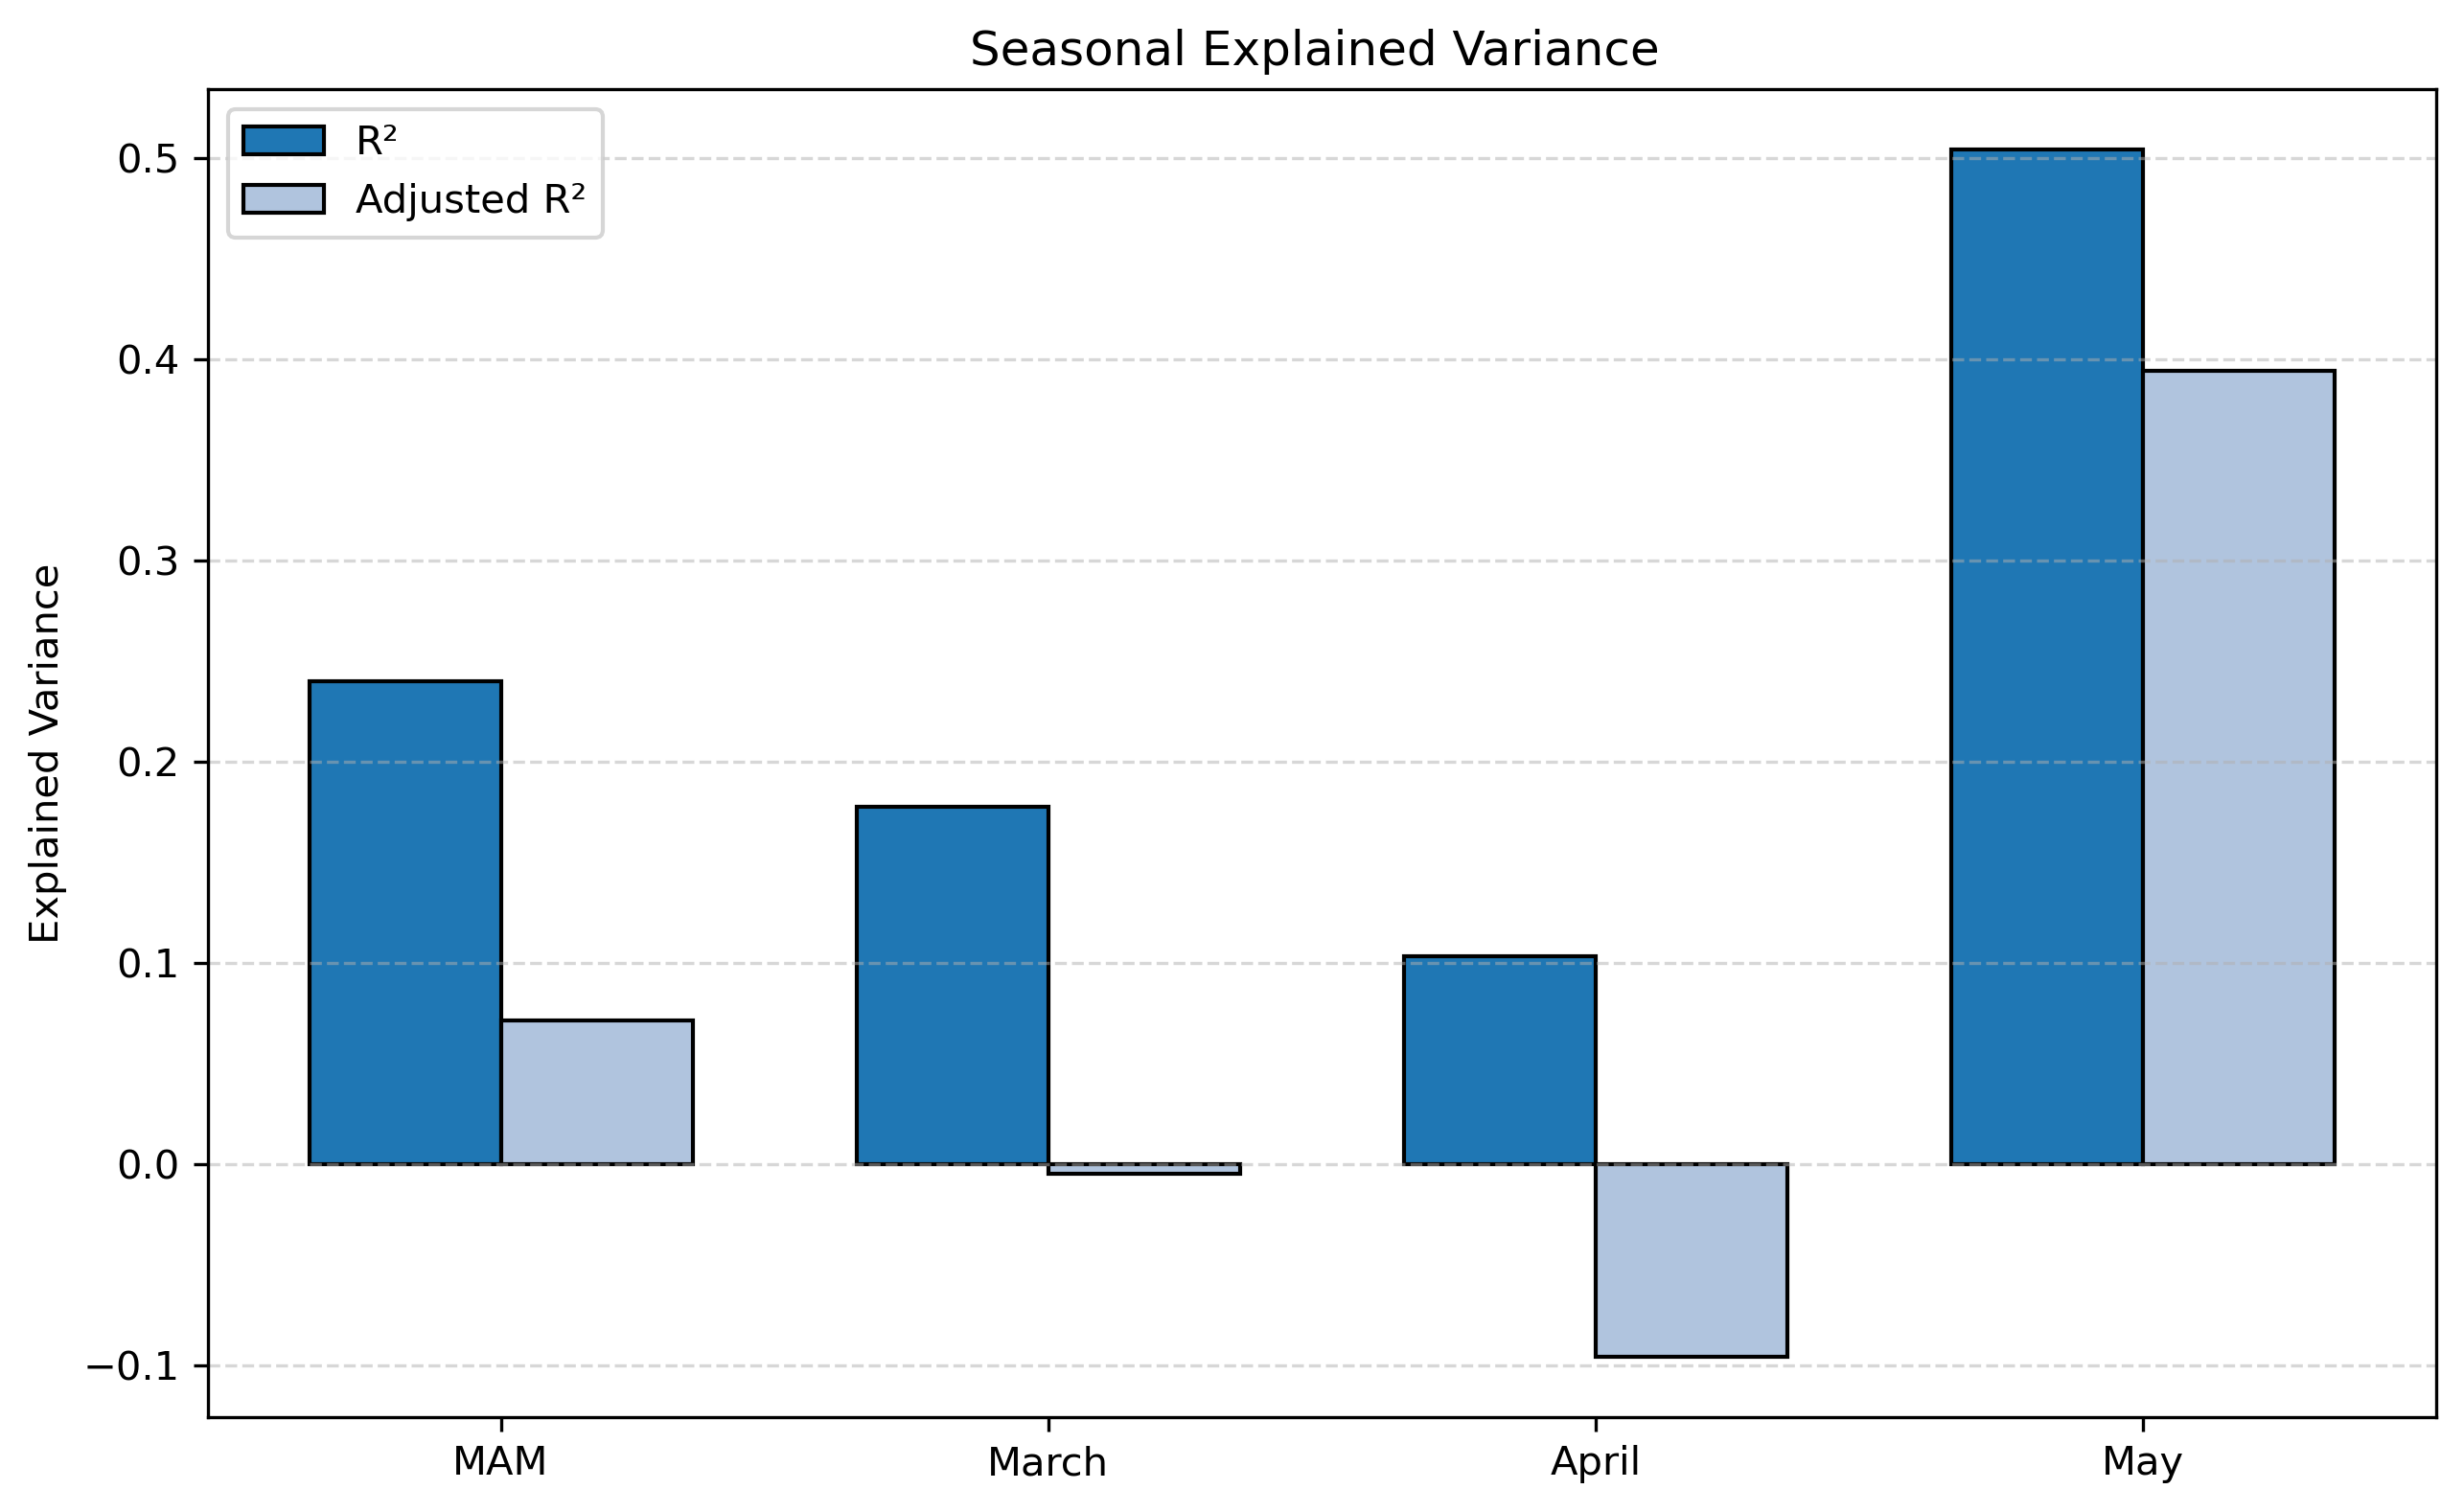

In [18]:
# =============================================================================
# 18. SEASONAL R2 SUMMARY PLOT
# =============================================================================
import matplotlib.pyplot as plt

def plot_r2_summary(fitted_models):
    periods = list(fitted_models.keys())
    r2_vals = [m.rsquared for m in fitted_models.values()]
    adj_r2_vals = [m.rsquared_adj for m in fitted_models.values()]
    
    x = np.arange(len(periods))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    ax.bar(x - width/2, r2_vals, width, label='R²', color='tab:blue', edgecolor='black')
    ax.bar(x + width/2, adj_r2_vals, width, label='Adjusted R²', color='lightsteelblue', edgecolor='black')
    
    ax.set_xticks(x)
    ax.set_xticklabels(periods)
    ax.set_ylabel("Explained Variance")
    ax.set_title("Seasonal Explained Variance ")
    ax.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

plot_r2_summary(fitted_models)

Calculating Decadal Trend Attribution...

--- Generating Attribution Subplot: MAM ---
--- Generating Attribution Subplot: March ---
--- Generating Attribution Subplot: April ---
--- Generating Attribution Subplot: May ---


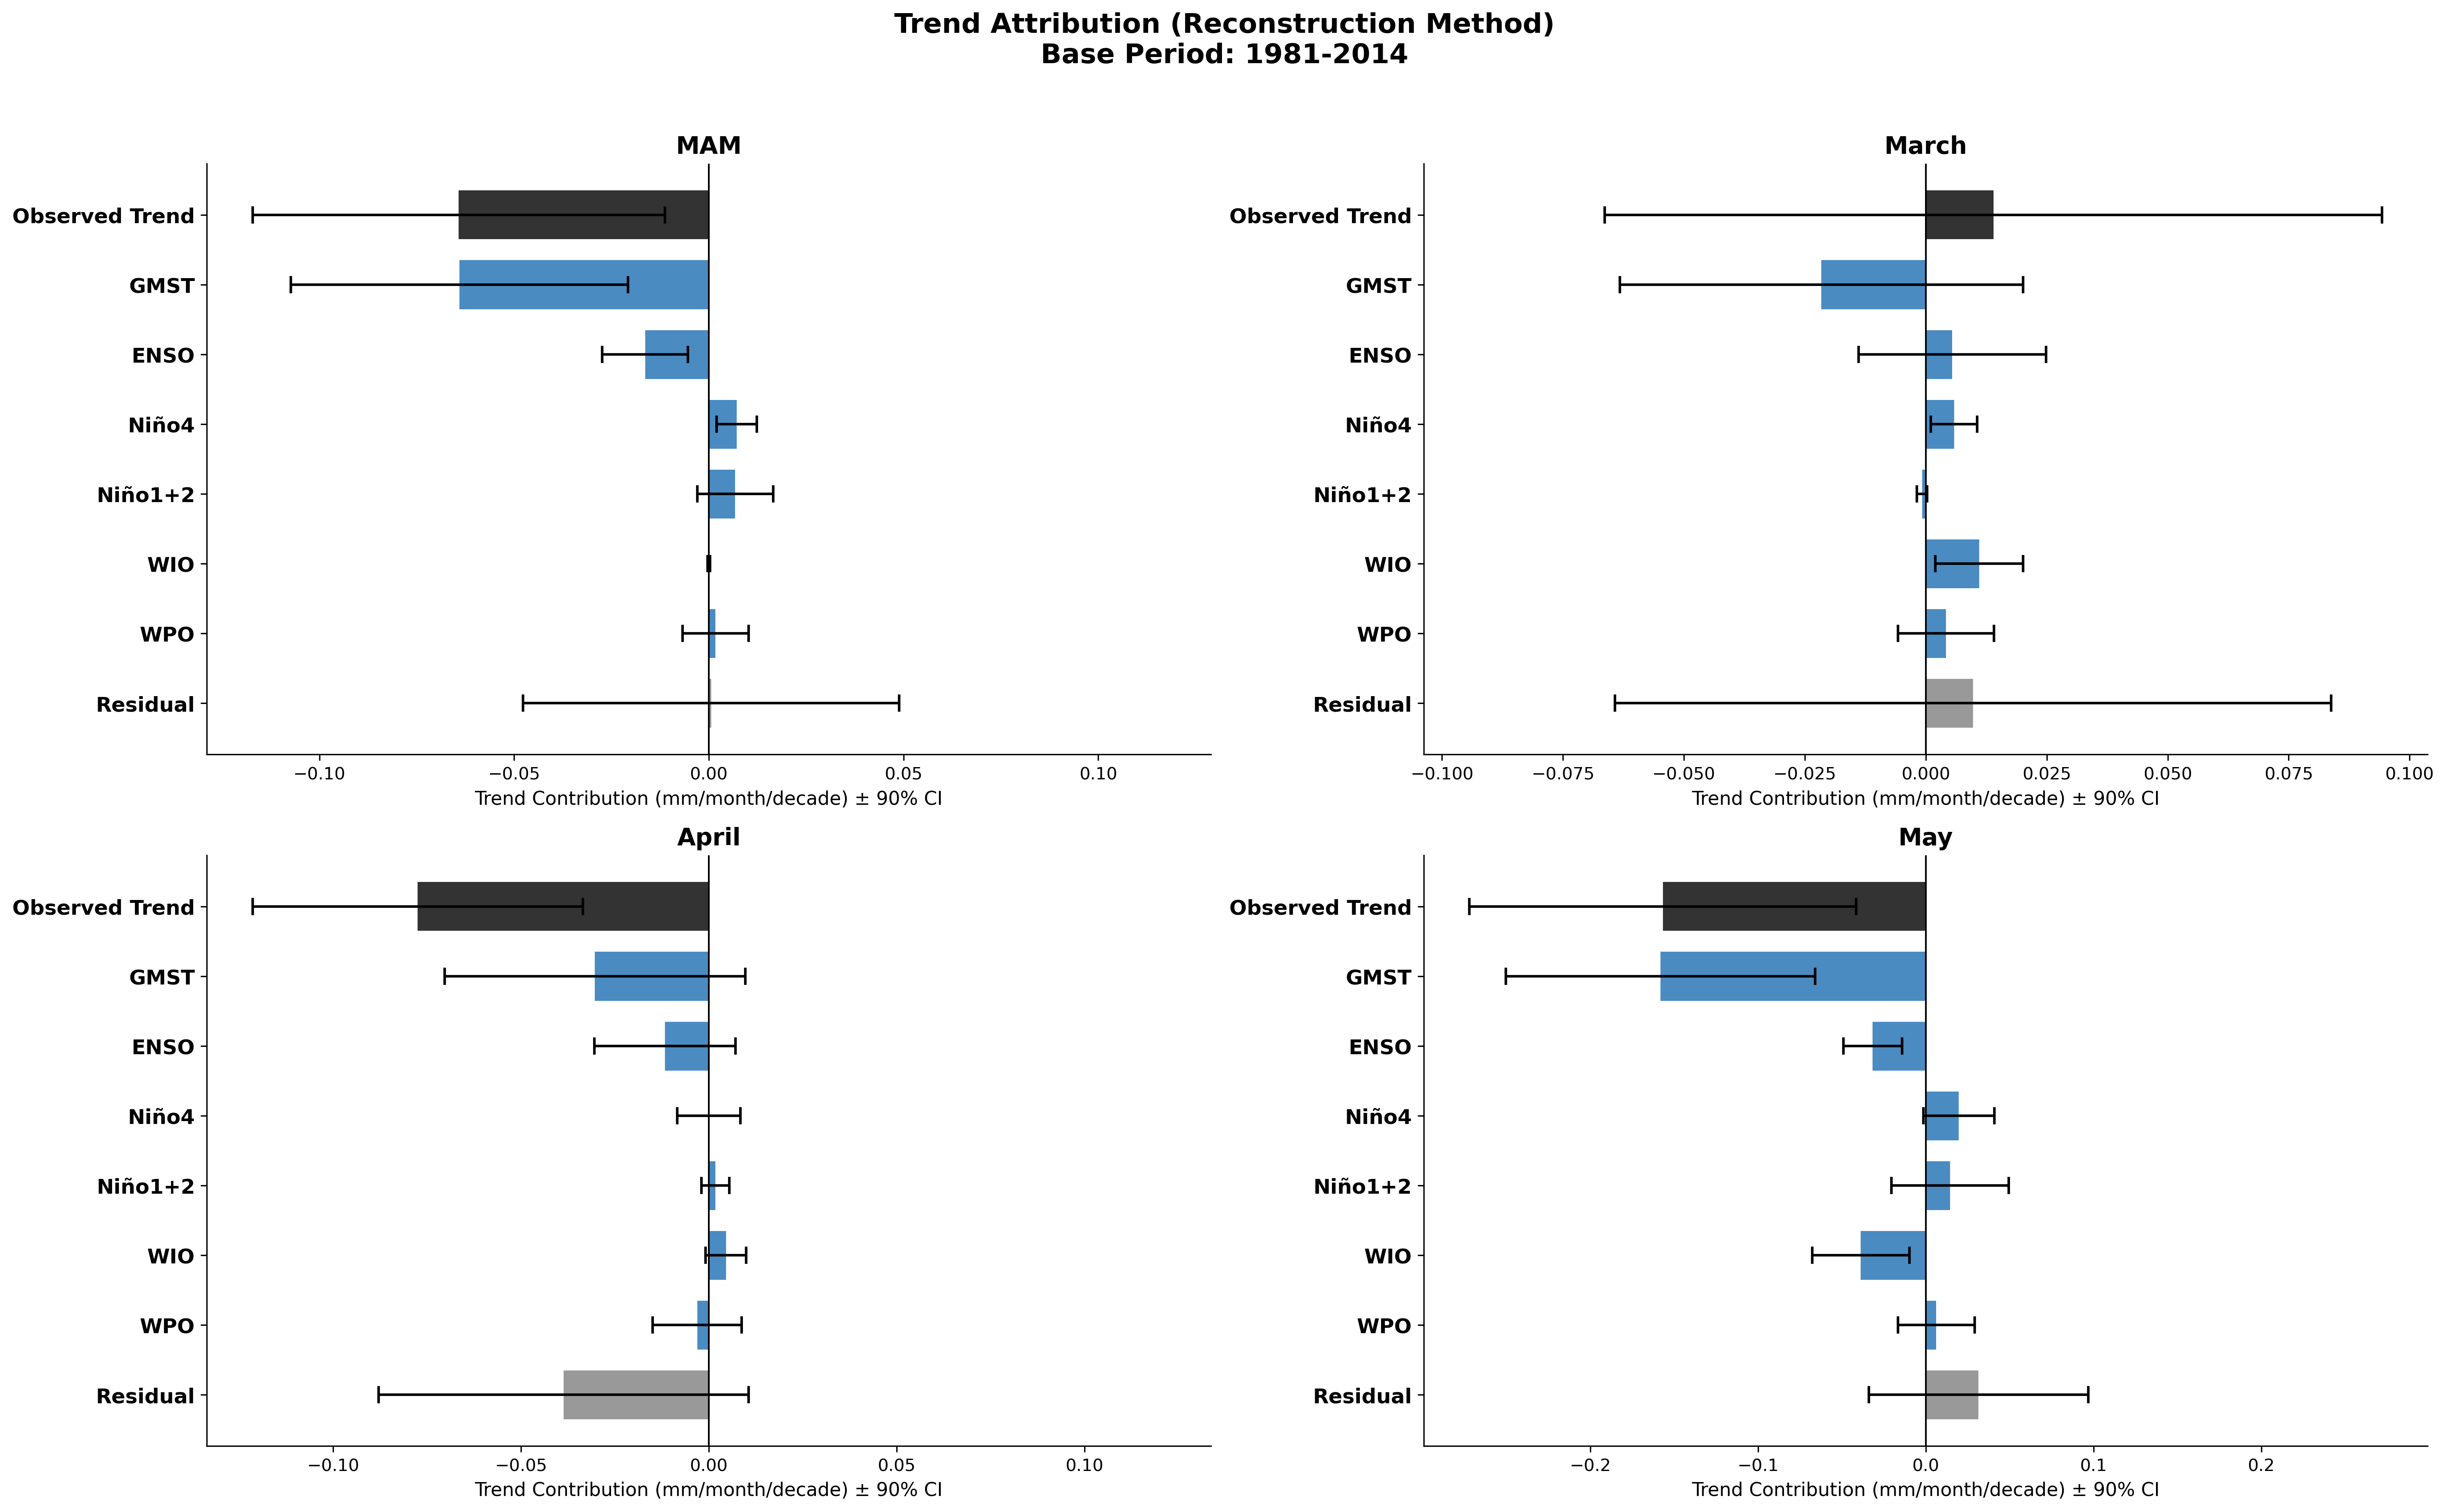

 💾 Saved composite attribution plot: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/attribution_bar_whiskers_composite.png
------------------------------------------------------------


In [20]:
# =============================================================================
# 17. TREND ATTRIBUTION BAR PLOT (WITH 90% CI WHISKERS)
# =============================================================================
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import math

print("Calculating Decadal Trend Attribution...\n")

# Determine optimal multi-panel grid layout for the periods (e.g., seasons)
num_periods = len(fitted_models)
cols = 2 if num_periods > 1 else 1
rows = math.ceil(num_periods / cols)

# Initialize a single composite figure
fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 6 * rows), dpi=300)

# Ensure axes is iterable even if there's only one plot
if num_periods == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, (period_name, model) in enumerate(fitted_models.items()):
    print(f"--- Generating Attribution Subplot: {period_name} ---")
    
    ax = axes[i]
    
    # 1. Extract Training Data
    df_ortho = orthogonalized_dfs[period_name]
    
    # Dynamically detect if we are using linear or log anomalies
    target_col = 'pr_anom' if 'pr_anom' in df_ortho.columns else 'pr_log_anom'
    
    # Strict mask for the base training period
    years = df_ortho.index.year if hasattr(df_ortho.index, 'year') else df_ortho.index.values
    mask_train = (years >= config.START_YEAR) & (years <= config.END_YEAR)
    df_train = df_ortho.loc[mask_train].dropna(subset=[target_col])
    
    valid_years = df_train.index.year if hasattr(df_train.index, 'year') else df_train.index.values
    time_x = sm.add_constant(valid_years)
    
    # 2. Setup Data Storage for the Plot
    plot_labels = []
    contributions = []
    errors = []
    colors = []
    
    # --- A. OBSERVED TREND ---
    obs_model = sm.OLS(df_train[target_col].values, time_x).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    obs_trend_decadal = obs_model.params[1] * 10
    obs_err_decadal = 1.645 * obs_model.bse[1] * 10  # 90% CI
    
    plot_labels.append('Observed Trend')
    contributions.append(obs_trend_decadal)
    errors.append(obs_err_decadal)
    colors.append('#333333') # Dark Charcoal
    
    # --- B. CLIMATE DRIVER CONTRIBUTIONS ---
    coeffs = model.params.drop('const')
    se = model.bse.drop('const')
    
    for predictor in coeffs.index:
        # Calculate the actual decadal trend of the driver
        driver_ts = df_train[predictor].values
        driver_model = sm.OLS(driver_ts, time_x).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
        driver_trend_annual = driver_model.params[1]
        
        # Contribution = Beta * Driver Trend * 10 years
        contrib = coeffs[predictor] * driver_trend_annual * 10
        
        # Error = 1.645 * SE(Beta) * abs(Driver Trend) * 10 years
        err = 1.645 * se[predictor] * abs(driver_trend_annual) * 10
        
        # Isolate the index/driver name by stripping standard suffixes
        clean_name = predictor.replace('orthonormal', '').replace('anom', '').replace('_', ' ').strip()
        
        plot_labels.append(clean_name)
        contributions.append(contrib)
        errors.append(err)
        colors.append('#4a8bc2') # Muted Blue
        
    # --- C. RESIDUAL TREND ---
    resid_ts = model.resid.values
    resid_model = sm.OLS(resid_ts, time_x).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    resid_trend_decadal = resid_model.params[1] * 10
    resid_err_decadal = 1.645 * resid_model.bse[1] * 10
    
    plot_labels.append('Residual')
    contributions.append(resid_trend_decadal)
    errors.append(resid_err_decadal)
    colors.append('#999999') # Neutral Gray
    
    # 3. Compile Plot DataFrame and Reverse for top-to-bottom reading
    plot_df = pd.DataFrame({
        'Label': plot_labels,
        'Contribution': contributions,
        'Error': errors,
        'Color': colors
    }).iloc[::-1] # Reverses order so Observed is at bottom, Residual at top
    
    # 4. Plotting on the specific subplot axis
    y_pos = np.arange(len(plot_df))
    
    ax.barh(y_pos, plot_df['Contribution'], color=plot_df['Color'], height=0.7, align='center')
    ax.errorbar(plot_df['Contribution'], y_pos, xerr=plot_df['Error'], 
                fmt='none', ecolor='black', capsize=5, capthick=1.5, elinewidth=1.5)
    
    # Formatting
    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['Label'], fontsize=12, fontweight='bold')
    ax.set_xlabel("Trend Contribution (mm/month/decade) ± 90% CI", fontsize=11)
    ax.set_title(f"{period_name}", fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    max_val = max(abs(plot_df['Contribution']) + plot_df['Error']) * 1.1
    ax.set_xlim(-max_val, max_val)

# Remove any empty subplots if the number of periods doesn't perfectly fill the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Apply a global title and tighten layout
plt.suptitle(f"Trend Attribution (Reconstruction Method)\nBase Period: {config.START_YEAR}-{config.END_YEAR}", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the multi-panel figure
save_path = config.FIGURE_DIR / "attribution_bar_whiskers_composite.png"
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(f" 💾 Saved composite attribution plot: {save_path}")
print("-" * 60)

Calculating Decadal Trend Attribution...

--- Generating Attribution Subplot: MAM ---
--- Generating Attribution Subplot: March ---
--- Generating Attribution Subplot: April ---
--- Generating Attribution Subplot: May ---


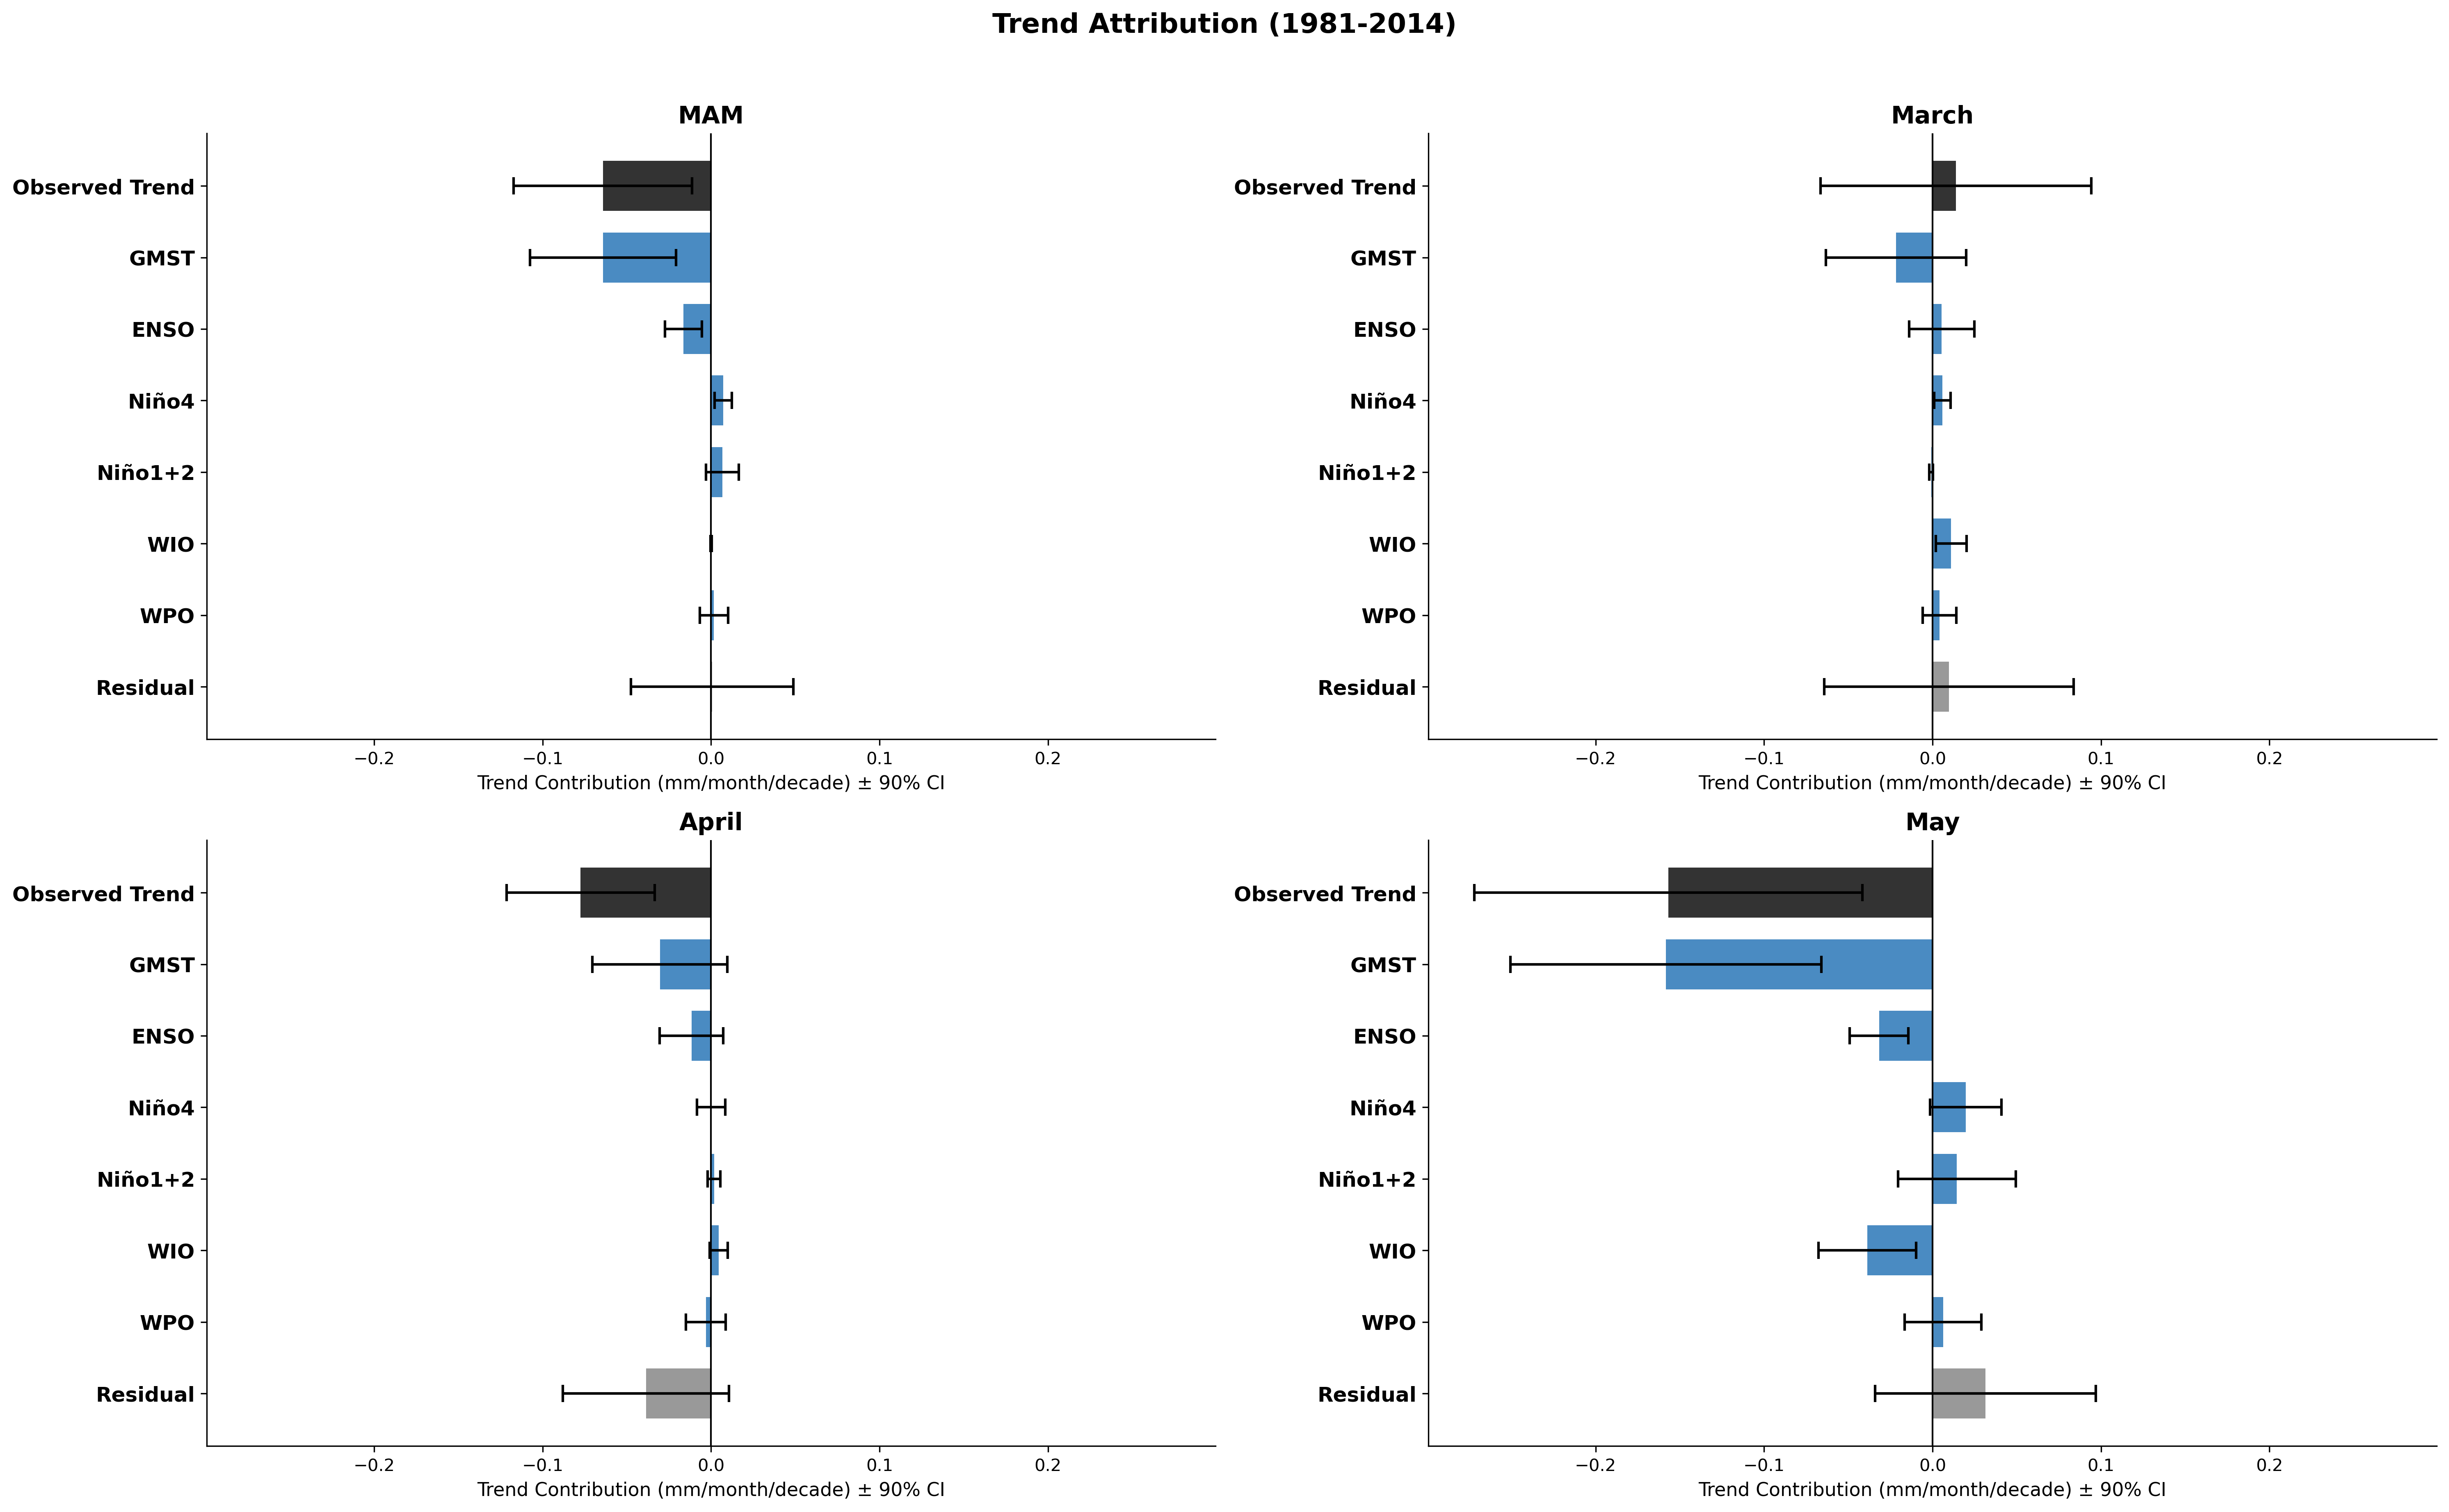

 💾 Saved composite attribution plot: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/attribution_bar_whiskers_composite.png
------------------------------------------------------------


In [21]:
# =============================================================================
# 17. TREND ATTRIBUTION BAR PLOT (WITH 90% CI WHISKERS)
# =============================================================================
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import math

print("Calculating Decadal Trend Attribution...\n")

# Determine optimal multi-panel grid layout for the periods (e.g., seasons)
num_periods = len(fitted_models)
cols = 2 if num_periods > 1 else 1
rows = math.ceil(num_periods / cols)

# Initialize a single composite figure
fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 6 * rows), dpi=300)

# Ensure axes is iterable even if there's only one plot
if num_periods == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Variable to track the absolute maximum value for unifying the x-axis
global_max_x = 0.0

for i, (period_name, model) in enumerate(fitted_models.items()):
    print(f"--- Generating Attribution Subplot: {period_name} ---")
    
    ax = axes[i]
    
    # 1. Extract Training Data
    df_ortho = orthogonalized_dfs[period_name]
    
    # Dynamically detect if we are using linear or log anomalies
    target_col = 'pr_anom' if 'pr_anom' in df_ortho.columns else 'pr_log_anom'
    
    # Strict mask for the base training period
    years = df_ortho.index.year if hasattr(df_ortho.index, 'year') else df_ortho.index.values
    mask_train = (years >= config.START_YEAR) & (years <= config.END_YEAR)
    df_train = df_ortho.loc[mask_train].dropna(subset=[target_col])
    
    valid_years = df_train.index.year if hasattr(df_train.index, 'year') else df_train.index.values
    time_x = sm.add_constant(valid_years)
    
    # 2. Setup Data Storage for the Plot
    plot_labels = []
    contributions = []
    errors = []
    colors = []
    
    # --- A. OBSERVED TREND ---
    obs_model = sm.OLS(df_train[target_col].values, time_x).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    obs_trend_decadal = obs_model.params[1] * 10
    obs_err_decadal = 1.645 * obs_model.bse[1] * 10  # 90% CI
    
    plot_labels.append('Observed Trend')
    contributions.append(obs_trend_decadal)
    errors.append(obs_err_decadal)
    colors.append('#333333') # Dark Charcoal
    
    # --- B. CLIMATE DRIVER CONTRIBUTIONS ---
    coeffs = model.params.drop('const')
    se = model.bse.drop('const')
    
    for predictor in coeffs.index:
        # Calculate the actual decadal trend of the driver
        driver_ts = df_train[predictor].values
        driver_model = sm.OLS(driver_ts, time_x).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
        driver_trend_annual = driver_model.params[1]
        
        # Contribution = Beta * Driver Trend * 10 years
        contrib = coeffs[predictor] * driver_trend_annual * 10
        
        # Error = 1.645 * SE(Beta) * abs(Driver Trend) * 10 years
        err = 1.645 * se[predictor] * abs(driver_trend_annual) * 10
        
        # Isolate the index/driver name by stripping standard suffixes
        clean_name = predictor.replace('orthonormal', '').replace('anom', '').replace('_', ' ').strip()
        
        plot_labels.append(clean_name)
        contributions.append(contrib)
        errors.append(err)
        colors.append('#4a8bc2') # Muted Blue
        
    # --- C. RESIDUAL TREND ---
    resid_ts = model.resid.values
    resid_model = sm.OLS(resid_ts, time_x).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    resid_trend_decadal = resid_model.params[1] * 10
    resid_err_decadal = 1.645 * resid_model.bse[1] * 10
    
    plot_labels.append('Residual')
    contributions.append(resid_trend_decadal)
    errors.append(resid_err_decadal)
    colors.append('#999999') # Neutral Gray
    
    # 3. Compile Plot DataFrame and Reverse for top-to-bottom reading
    plot_df = pd.DataFrame({
        'Label': plot_labels,
        'Contribution': contributions,
        'Error': errors,
        'Color': colors
    }).iloc[::-1] # Reverses order so Observed is at bottom, Residual at top
    
    # 4. Plotting on the specific subplot axis
    y_pos = np.arange(len(plot_df))
    
    ax.barh(y_pos, plot_df['Contribution'], color=plot_df['Color'], height=0.7, align='center')
    ax.errorbar(plot_df['Contribution'], y_pos, xerr=plot_df['Error'], 
                fmt='none', ecolor='black', capsize=5, capthick=1.5, elinewidth=1.5)
    
    # Formatting
    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['Label'], fontsize=12, fontweight='bold')
    ax.set_xlabel("Trend Contribution (mm/month/decade) ± 90% CI", fontsize=11)
    ax.set_title(f"{period_name}", fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Track the absolute maximum limit required across all subplots
    local_max = max(abs(plot_df['Contribution']) + plot_df['Error']) * 1.1
    global_max_x = max(global_max_x, local_max)

# Apply the unified x-axis scale to all active subplots
for ax in axes[:num_periods]:
    ax.set_xlim(-global_max_x, global_max_x)

# Remove any empty subplots if the number of periods doesn't perfectly fill the grid
for j in range(num_periods, len(axes)):
    fig.delaxes(axes[j])

# Apply a global title and tighten layout
plt.suptitle(f"Trend Attribution ({config.START_YEAR}-{config.END_YEAR})", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the multi-panel figure
save_path = config.FIGURE_DIR / "attribution_bar_whiskers_composite.png"
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(f" 💾 Saved composite attribution plot: {save_path}")
print("-" * 60)

Generating Shaded Attributed Variability Time Series Plots...

--- Generating Shaded Subplot: MAM ---
--- Generating Shaded Subplot: March ---
--- Generating Shaded Subplot: April ---
--- Generating Shaded Subplot: May ---


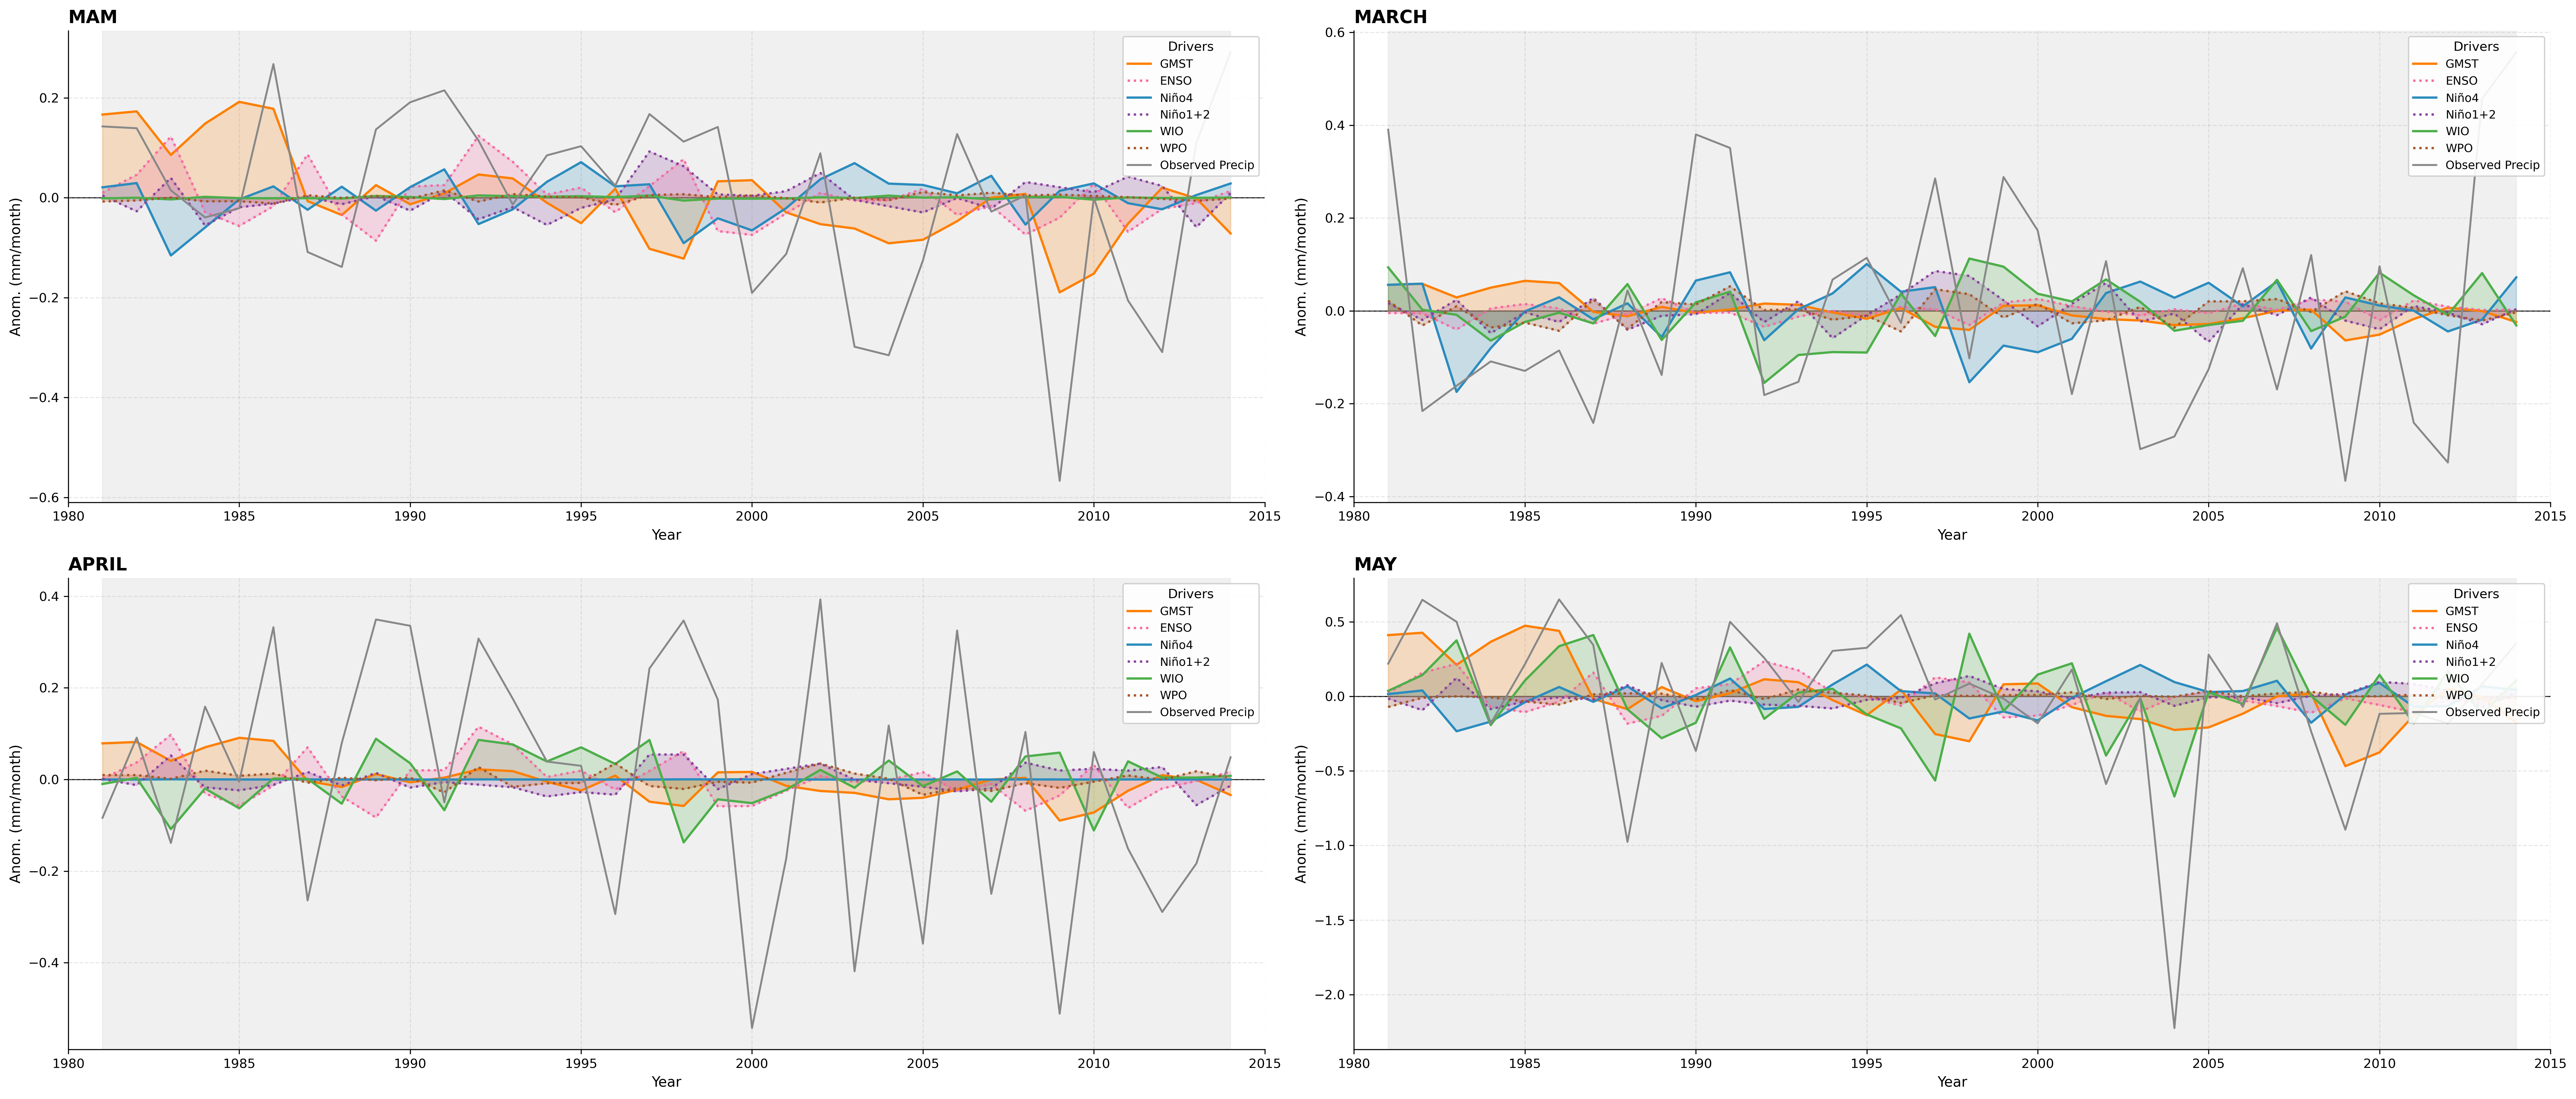

 💾 Saved shaded attributed variability plot: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/attributed_variability_shaded_composite.png
------------------------------------------------------------


In [22]:
# =============================================================================
# 19. ATTRIBUTED VARIABILITY TIME SERIES PLOT (SHADED AREA STYLE)
# =============================================================================
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import math

print("Generating Shaded Attributed Variability Time Series Plots...\n")

# Determine optimal multi-panel grid layout (e.g., 2x2 for 4 periods)
num_periods = len(fitted_models)
cols = 2 if num_periods > 1 else 1
rows = math.ceil(num_periods / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14 * cols, 6 * rows), dpi=300)

if num_periods == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Distinct color palette matching standard climate driver conventions
# (e.g., Orange/Pink for ENSO modes, Blue for WPO, Purple for WIO)
palette = ['#ff7f00', '#f768a1', '#2b8cbe', '#88419d', '#4daf4a', '#a65628']

for i, (period_name, model) in enumerate(fitted_models.items()):
    print(f"--- Generating Shaded Subplot: {period_name} ---")
    ax = axes[i]
    
    # 1. Extract Training Data
    df_ortho = orthogonalized_dfs[period_name]
    target_col = 'pr_anom' if 'pr_anom' in df_ortho.columns else 'pr_log_anom'
    
    years = df_ortho.index.year if hasattr(df_ortho.index, 'year') else df_ortho.index.values
    mask_train = (years >= config.START_YEAR) & (years <= config.END_YEAR)
    df_train = df_ortho.loc[mask_train].dropna(subset=[target_col])
    valid_years = df_train.index.year if hasattr(df_train.index, 'year') else df_train.index.values
    
    # 2. Add Background Shaded Reference Span (Training / Base Climatology Period)
    ax.axvspan(config.START_YEAR, config.END_YEAR, color='#ebebeb', alpha=0.7, zorder=0, label='_nolegend_')
    
    # 3. Plot Individual Driver Contributions with Shaded Areas
    coeffs = model.params.drop('const')
    
    for idx, predictor in enumerate(coeffs.index):
        clean_name = predictor.replace('orthonormal', '').replace('anom', '').replace('_', ' ').strip()
        color = palette[idx % len(palette)]
        
        # Calculate time series contribution: Beta * Driver_TS(t)
        driver_contrib_ts = df_train[predictor].values * coeffs[predictor]
        
        # Shaded area between 0 and the driver anomaly
        ax.fill_between(valid_years, 0, driver_contrib_ts, color=color, alpha=0.2, zorder=2)
        
        # Driver boundary line (alternating solid and dotted/dashed for visual distinction)
        linestyle = ':' if idx % 2 == 1 else '-'
        ax.plot(valid_years, driver_contrib_ts, color=color, linestyle=linestyle, linewidth=1.8, 
                label=clean_name, zorder=3)
        
    # 4. Plot Observed Precipitation Overlaid on Top
    obs_ts = df_train[target_col].values
    ax.plot(valid_years, obs_ts, color='#888888', linewidth=1.5, label='Observed Precip', zorder=4)
    
    # 5. Formatting & Aesthetics
    ax.axhline(0, color='black', linewidth=0.8, zorder=1)
    ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
    
    # Title styled like "Attributed Variability: MAM"
    ax.set_title(f"{period_name.upper()}", fontsize=14, fontweight='bold', loc='left')
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Anom. (mm/month)", fontsize=11)
    
    # Set x-limits with padding around the time series
    ax.set_xlim(valid_years.min() - 1, valid_years.max() + 1)
    
    # Legend styled with a title box outside or in an open corner
    ax.legend(title='Drivers', loc='upper right', fontsize=9, title_fontsize=10, 
              frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Remove any unused subplots from the grid
for j in range(num_periods, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the multi-panel figure
save_path = config.FIGURE_DIR / "attributed_variability_shaded_composite.png"
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(f" 💾 Saved shaded attributed variability plot: {save_path}")
print("-" * 60)

Generating Clean 3-Year Smoothed Attributed Variability Plots...

--- Generating Clean Subplot: MAM ---
--- Generating Clean Subplot: March ---
--- Generating Clean Subplot: April ---
--- Generating Clean Subplot: May ---


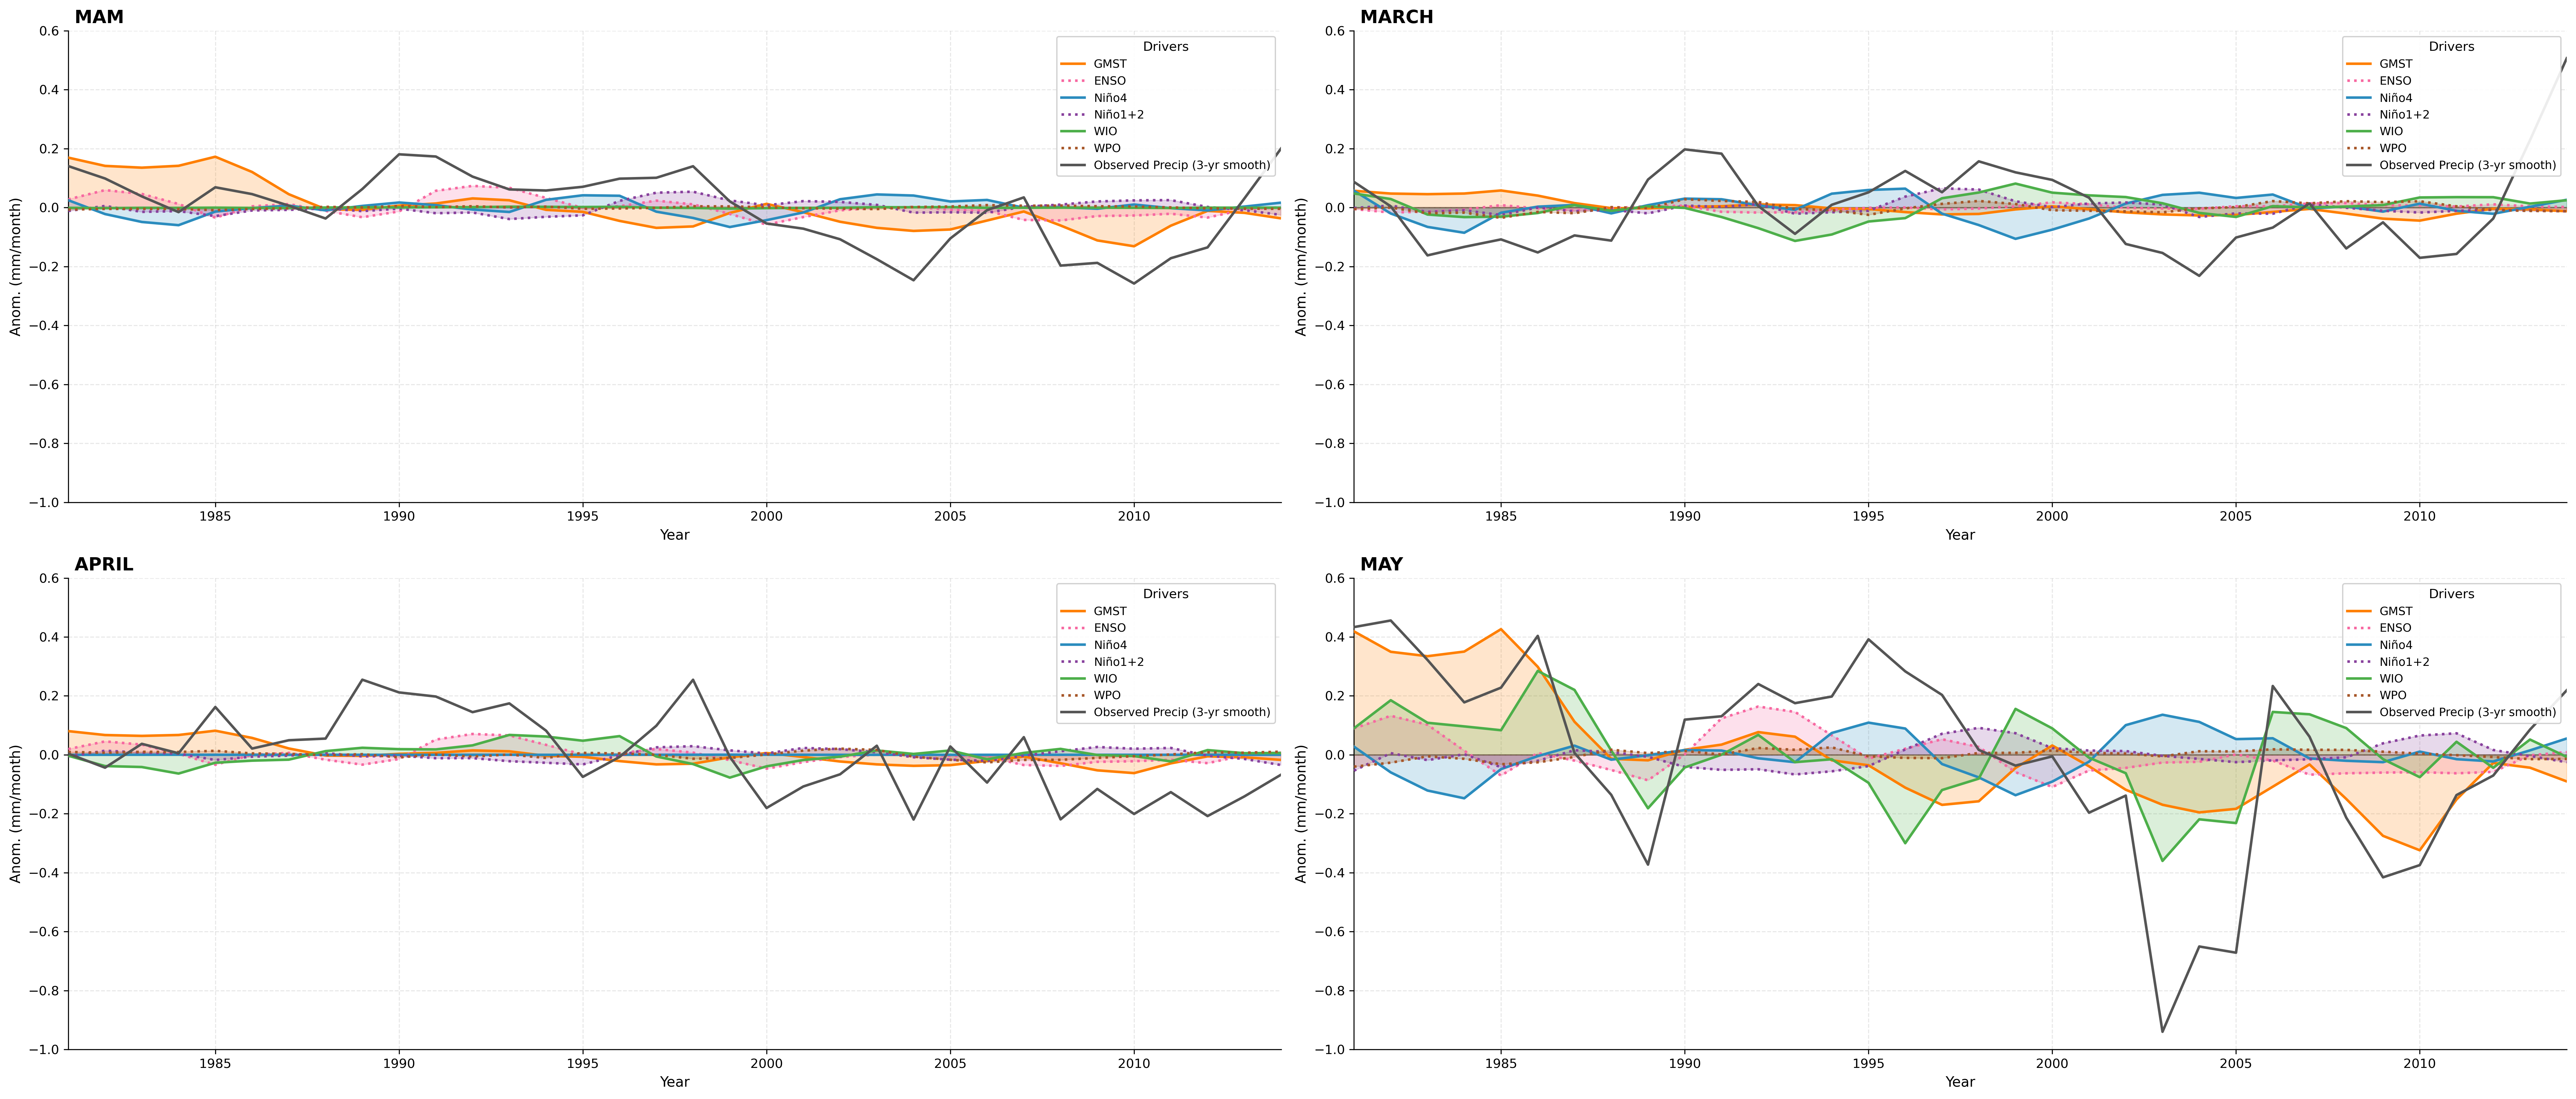

 💾 Saved clean plot without background line: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/attributed_variability_clean.png
------------------------------------------------------------


In [23]:
# =============================================================================
# 20. ATTRIBUTED VARIABILITY TIME SERIES PLOT (CLEAN, NO RAW BACKGROUND LINE)
# =============================================================================
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import math

print("Generating Clean 3-Year Smoothed Attributed Variability Plots...\n")

# Determine grid layout (2x2 for 4 periods)
num_periods = len(fitted_models)
cols = 2 if num_periods > 1 else 1
rows = math.ceil(num_periods / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14 * cols, 6 * rows), dpi=300)

if num_periods == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Distinct color palette for climate drivers
palette = ['#ff7f00', '#f768a1', '#2b8cbe', '#88419d', '#4daf4a', '#a65628']

for i, (period_name, model) in enumerate(fitted_models.items()):
    print(f"--- Generating Clean Subplot: {period_name} ---")
    ax = axes[i]
    
    # 1. Extract Training Data
    df_ortho = orthogonalized_dfs[period_name]
    target_col = 'pr_anom' if 'pr_anom' in df_ortho.columns else 'pr_log_anom'
    
    years = df_ortho.index.year if hasattr(df_ortho.index, 'year') else df_ortho.index.values
    mask_train = (years >= config.START_YEAR) & (years <= config.END_YEAR)
    df_train = df_ortho.loc[mask_train].dropna(subset=[target_col])
    valid_years = df_train.index.year if hasattr(df_train.index, 'year') else df_train.index.values
    
    # 2. Plot Individual Driver Contributions with 3-Year Smoothing
    coeffs = model.params.drop('const')
    
    for idx, predictor in enumerate(coeffs.index):
        clean_name = predictor.replace('orthonormal', '').replace('anom', '').replace('_', ' ').strip()
        color = palette[idx % len(palette)]
        
        # Calculate raw annual contribution
        raw_contrib = df_train[predictor].values * coeffs[predictor]
        
        # Apply 3-year moving average
        smooth_contrib = pd.Series(raw_contrib).rolling(window=3, center=True, min_periods=1).mean().values
        
        # Shaded area between 0 and the smoothed driver line
        ax.fill_between(valid_years, 0, smooth_contrib, color=color, alpha=0.2, zorder=2)
        
        # Smoothed driver boundary line
        linestyle = ':' if idx % 2 == 1 else '-'
        ax.plot(valid_years, smooth_contrib, color=color, linestyle=linestyle, linewidth=2.0, 
                label=clean_name, zorder=3)
        
    # 3. Plot Observed Precipitation (Only the 3-Year Smoothed Line)
    obs_raw = df_train[target_col].values
    obs_smooth = pd.Series(obs_raw).rolling(window=3, center=True, min_periods=1).mean().values
    
    # Smoothed observed line
    ax.plot(valid_years, obs_smooth, color='#555555', linewidth=2.0, label='Observed Precip (3-yr smooth)', zorder=4)
    
    # 4. Formatting & Aesthetics
    ax.axhline(0, color='black', linewidth=0.8, zorder=1)
    ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
    
    ax.set_title(f" {period_name.upper()}", fontsize=14, fontweight='bold', loc='left')
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Anom. (mm/month)", fontsize=11)
    
    # Lock the x-axis to 1980 - 2014
    ax.set_xlim(config.START_YEAR, config.END_YEAR)
    
    # Lock the y-axis strictly between -0.6 and +0.6
    ax.set_ylim(-1, 0.6)
    
    ax.legend(title='Drivers', loc='upper right', fontsize=9, title_fontsize=10, 
              frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Remove any unused empty charts from the grid
for j in range(num_periods, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the figure
save_path = config.FIGURE_DIR / "attributed_variability_clean.png"
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(f" 💾 Saved clean plot without background line: {save_path}")
print("-" * 60)